## Setup

In [ ]:
# Written by AlchemYst-Crucible, the analysis architecture of AlkhemYst-Ai.
#
# Not written by hand. Every step below corresponds to a component on the
# pipeline canvas, and the settings it runs with are the ones set there.
suppressPackageStartupMessages({
  library(jsonlite)
  library(data.table)
  library(ggplot2)
})

dir.create("artifacts", showWarnings = FALSE, recursive = TRUE)

# An environment, not a list. R copies a list on assignment, so a helper that
# appended to one would write into its own copy and the caller would never see
# it. That is how a run reports success with no metrics at all.
METRICS <- new.env(parent = emptyenv())

metric <- function(node_id, name, value) {
  # Every measurement belongs to the step that made it. The key is what lets
  # the interface show a component's own numbers when it is opened, instead of
  # one pile for the whole run.
  assign(paste0(node_id, "::", name), value, envir = METRICS)
  invisible(value)
}

.wrap_labels <- function(x, width = 45) {
  # str_wrap without depending on stringr being attached.
  vapply(as.character(x), function(s) {
    if (is.na(s) || nchar(s) <= width) return(s)
    paste(strwrap(s, width = width), collapse = "\n")
  }, character(1), USE.NAMES = FALSE)
}

.fit_categories <- function(plot, height) {
  # A FIGURE WITH A ROW PER CATEGORY MUST BE SIZED BY THE CATEGORIES.
  #
  # THE FAULT. An enrichment barplot draws twenty GO terms in whatever frame it
  # is given. "positive regulation of endothelial cell migration" is 56
  # characters, so the label wraps to a second line, the row does not grow to
  # take it, and consecutive terms print through each other. The figure looks
  # finished and cannot be read, which is worse than one that failed, because
  # nothing downstream questions a PNG that exists.
  #
  # This lives here, in the scaffolding, because three runs of telling the
  # coder to size its own figures produced three figures of the same size. A
  # rule the model may skip is not a control; every figure goes through
  # save_fig whether the coder thought about it or not.
  #
  # Anything that throws leaves the plot exactly as it was: a figure drawn at
  # the wrong height is a poor figure, and a figure lost to an error in the
  # code that was trying to improve it is no figure at all.
  tryCatch({
    if (!inherits(plot, "ggplot")) return(list(plot = plot, height = height))
    built <- ggplot2::ggplot_build(plot)
    params <- built$layout$panel_params[[1]]
    labels <- NULL
    if (!is.null(params$y) && !is.null(params$y$get_labels)) {
      labels <- params$y$get_labels()
    }
    labels <- labels[!is.na(labels)]
    # A discrete axis of words, not a numeric scale that happens to print as
    # text: every tick has to be non-numeric before anything is changed.
    if (length(labels) < 3 || !any(is.na(suppressWarnings(as.numeric(labels))))) {
      return(list(plot = plot, height = height))
    }
    longest <- max(nchar(labels))
    if (longest > 24) {
      plot <- plot + ggplot2::scale_y_discrete(labels = .wrap_labels)
      # Wrapping buys legibility at the cost of vertical space, so the rows
      # have to allow for the extra lines it creates.
      lines_each <- ceiling(longest / 45)
      height <- max(height, 0.34 * length(labels) * lines_each + 1.6)
    } else {
      height <- max(height, 0.30 * length(labels) + 1.4)
    }
    list(plot = plot, height = min(height, 24))   # ggsave refuses past ~50in
  }, error = function(e) list(plot = plot, height = height))
}

save_fig <- function(plot, name, width = 7.2, height = 4.8, dpi = 110) {
  # Takes what survminer and its relatives actually return.
  #
  # ggsurvplot() and ggcoxzph() return LISTS, and ggsave() has no method for
  # them: the run dies in grid.draw after the analysis is finished, with an
  # error naming neither the plot nor the package. Printing into a device
  # handles every case and is the only way the risk table and the
  # per-covariate panels survive.
  # NOTHING IS NOT A FIGURE.
  #
  # A step drew with pheatmap and then handed this function a NULL, under a
  # comment claiming save_fig handles pheatmap objects. It does not, and
  # nothing said so: print(NULL) put two bare NULLs in the log, no image was
  # written, and the step reported done. The canvas showed a heatmap step that
  # had run and there was no heatmap. A silent absence is worse than a failure,
  # because a failure gets corrected and this got believed.
  #
  # pheatmap draws to the device and returns its object invisibly, so the
  # figure has to be captured rather than assumed:
  #     p <- pheatmap::pheatmap(mat, silent = TRUE); save_fig(p, "name")
  if (is.null(plot)) {
    stop(sprintf(
      paste0("save_fig('%s') was given NULL, so there is no figure to save. ",
             "Capture the plot object and pass it: for pheatmap, ",
             "p <- pheatmap::pheatmap(mat, silent = TRUE); save_fig(p, '%s')"),
      name, name))
  }
  fitted <- .fit_categories(plot, height)
  plot <- fitted$plot
  height <- fitted$height
  path <- file.path("artifacts", paste0(name, ".png"))
  ok <- tryCatch({
    if (inherits(plot, "ggplot")) {
      ggplot2::ggsave(path, plot = plot, width = width, height = height, dpi = dpi)
    } else {
      grDevices::png(path, width = width * dpi, height = height * dpi, res = dpi)
      print(plot)
      grDevices::dev.off()
    }
    TRUE
  }, error = function(e) {
    message(sprintf("could not save figure '%s': %s", name, conditionMessage(e)))
    FALSE
  })
  invisible(ok)
}

emit_preview <- function(node_id, df, rows = 5) {
  # The table a step produced, as the interface shows it. A transform that
  # reports no metric still has to prove it ran, and its preview is that
  # proof.
  df <- as.data.frame(df)
  n <- min(rows, nrow(df))
  prev <- list(
    rows = nrow(df),
    columns = ncol(df),
    sample_columns = as.list(utils::head(names(df), 500)),
    sample = if (n > 0) unname(lapply(seq_len(n), function(i) {
      as.list(lapply(df[i, , drop = FALSE], function(v) {
        if (is.na(v[1])) NULL else as.character(v[1])
      }))
    })) else list()
  )
  jsonlite::write_json(prev, file.path("artifacts", paste0(node_id, "__preview.json")),
                       auto_unbox = TRUE, null = "null")
  invisible(NULL)
}

annotation_frame <- function(values, cols) {
  # The annotation pheatmap actually accepts.
  #
  # pheatmap matches annotations to the matrix BY NAME, so the thing it wants
  # is a data.frame whose row names are the matrix's column names. Neither
  # obvious wrong answer survives: a named list fails with "incorrect number
  # of dimensions", because a list indexed in two dimensions is not a thing,
  # and a data.frame with no row names fails later and less helpfully inside
  # grid with "'gpar' element 'fill' must not be length 0". Both were
  # reproduced against the real package before this was written.
  #
  # The failure lands after the analysis is finished and the figure is the
  # last thing the step does, so it costs the whole step rather than the
  # picture.
  #
  # THE COLUMN IS NAMED AFTER THE EXPRESSION THAT PRODUCED IT.
  #
  # It used to be named "Group" always. Four annotations built from one sample
  # table and cbind-ed together were then four columns all called Group, and
  # pheatmap died on "Factor levels on variable Group do not match with
  # annotation_colors" -- after edgeR had run, so it cost the heatmap step and
  # every step downstream of it. deparse(substitute()) needs nothing of the
  # caller: annotation_frame(samples$condition, ...) names itself "condition".
  name <- deparse(substitute(values))
  df <- as.data.frame(values, stringsAsFactors = FALSE)
  if (ncol(df) == 1 && is.null(names(values))) {
    name <- sub("^.*\\$", "", name[1])          # samples$condition -> condition
    name <- sub("^.*\\[\\[\"?", "", name)        # meta[["hours"]]    -> hours"]]
    name <- gsub("[^A-Za-z0-9_.]", "", name)
    if (!nzchar(name) || grepl("^[0-9.]", name)) name <- "Group"
    names(df) <- name
  }
  rownames(df) <- cols
  df
}

# The command-line tools a step may run, and the only way to run them.
#
# A generated program may not call the shell (system, system2 and the rest
# are refused by the harness), because a program that can run anything can
# read, write or send anything. Sequencing work still needs a handful of
# standard tools that have no R equivalent: cutadapt to remove primers,
# FastQC for the read report, MAFFT and FastTree for the phylogeny, PICRUSt2
# for predicted function. So there is one door, here in the scaffold the
# platform owns: a fixed list of installed programs, run by absolute path with
# their arguments passed one by one and never through a shell, inside the
# run's own sandbox (no network), with a time limit. What each tool printed is
# kept as an artifact of the step that ran it.
.RUN_TOOLS <- list(
  cutadapt = "/usr/bin/cutadapt",
  fastqc = "/usr/bin/fastqc",
  mafft = "/usr/bin/mafft",
  FastTree = "/usr/bin/fasttree",
  picrust2_pipeline.py = "/opt/picrust2/bin/picrust2_pipeline.py",
  pathway_pipeline.py = "/opt/picrust2/bin/pathway_pipeline.py",
  add_descriptions.py = "/opt/picrust2/bin/add_descriptions.py"
)

run_tool <- function(tool, args = character(), node_id = NULL, stdout_file = NULL, timeout = 7200) {
  path <- .RUN_TOOLS[[tool]]
  if (is.null(path)) {
    stop(sprintf("run_tool: '%s' is not one of the tools a step may run (%s)", tool,
                 paste(names(.RUN_TOOLS), collapse = ", ")), call. = FALSE)
  }
  if (!file.exists(path)) stop(sprintf("run_tool: %s is not installed on this runner", tool), call. = FALSE)
  args <- as.character(unlist(args))
  # PICRUSt2 calls its own helpers (EPA-ng, gappa, HMMER, its R) by name
  env <- if (startsWith(path, "/opt/picrust2/")) c("current", PATH = paste("/opt/picrust2/bin", Sys.getenv("PATH"), sep = ":")) else "current"
  res <- processx::run(path, args, error_on_status = FALSE, timeout = timeout, env = env,
                       stdout = if (is.null(stdout_file)) "|" else stdout_file, stderr = "|")
  if (!is.null(node_id)) {
    log <- c(sprintf("$ %s %s", tool, paste(shQuote(args), collapse = " ")), "",
             if (is.null(stdout_file)) res$stdout else sprintf("(output written to %s)", stdout_file), res$stderr)
    writeLines(log, file.path("artifacts", sprintf("%s__%s.log", node_id, gsub("[^A-Za-z0-9]+", "_", tool))))
  }
  if (isTRUE(res$timeout)) stop(sprintf("run_tool: %s did not finish within %d seconds", tool, timeout), call. = FALSE)
  if (!identical(res$status, 0L)) {
    tail_err <- paste(utils::tail(strsplit(res$stderr, "\n")[[1]], 12), collapse = "\n")
    stop(sprintf("run_tool: %s exited with status %s\n%s", tool, res$status, tail_err), call. = FALSE)
  }
  invisible(res)
}

step_start <- function(node_id, i, total, label) {
  print(sprintf("[[step]] %s start %d/%d ▶ %s", node_id, i, total, label))
  flush.console()
}

step_done <- function(node_id, i, total, label) {
  print(sprintf("[[step]] %s done %d/%d ✓ %s", node_id, i, total, label))
  flush.console()
}

# A step that cannot do its work says so and the run continues. A step that
# stops the program takes every later step with it, including the ones that
# would have worked, and the researcher loses the whole run over one column.
step_skipped <- function(node_id, why) {
  metric(node_id, "skipped", why)
  message(sprintf("%s: %s", node_id, why))
  invisible(NULL)
}

## Dataset

In [ ]:
step_start("n0", 1, 15, "Dataset")
DATA_ARCHIVE <- "data/miseq_sop_16S.zip"
TABLE_FILES <- list.files("data", pattern = "[.](csv|tsv|txt)([.]gz)?$", full.names = TRUE)
READ_FILES <- sort(list.files("data", pattern = "[.](fastq|fq)([.]gz)?$", full.names = TRUE))
read_any <- function(path) {
  ext <- tolower(tools::file_ext(path))
  if (ext == "tsv") data.table::fread(path, sep = "\t", data.table = FALSE)
  else data.table::fread(path, data.table = FALSE)
}
DATA_FILE <- if (length(TABLE_FILES)) TABLE_FILES[which.max(file.size(TABLE_FILES))] else DATA_ARCHIVE
df <- if (length(TABLE_FILES)) read_any(DATA_FILE) else data.frame()
metric("n0", "rows", nrow(df))
metric("n0", "columns", ncol(df))
metric("n0", "read_files", length(READ_FILES))
if (nrow(df)) emit_preview("n0", df)
print(sprintf("archive %s: %d read files, sample table %s (%d rows)", DATA_ARCHIVE,
              length(READ_FILES), basename(DATA_FILE), nrow(df)))
step_done("n0", 1, 15, "Dataset")

## Read Quality Report

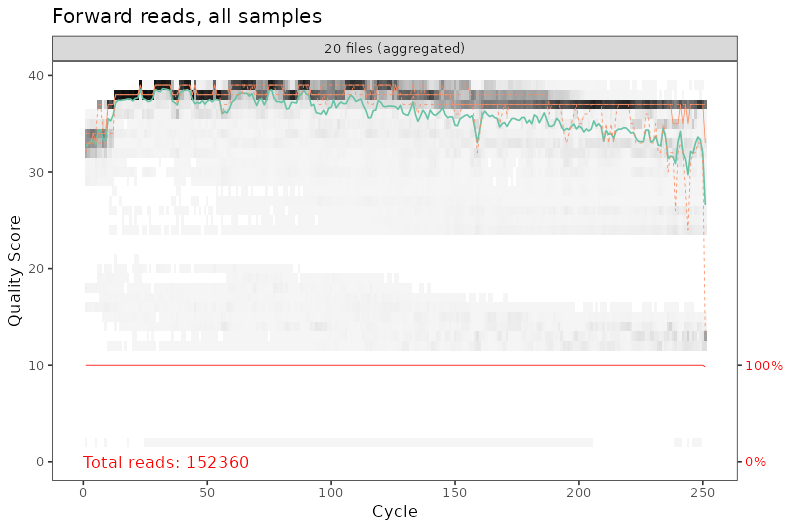

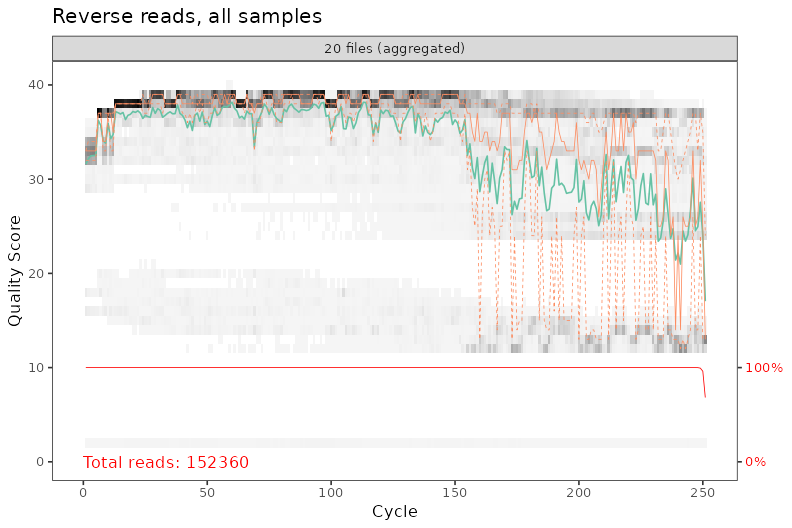

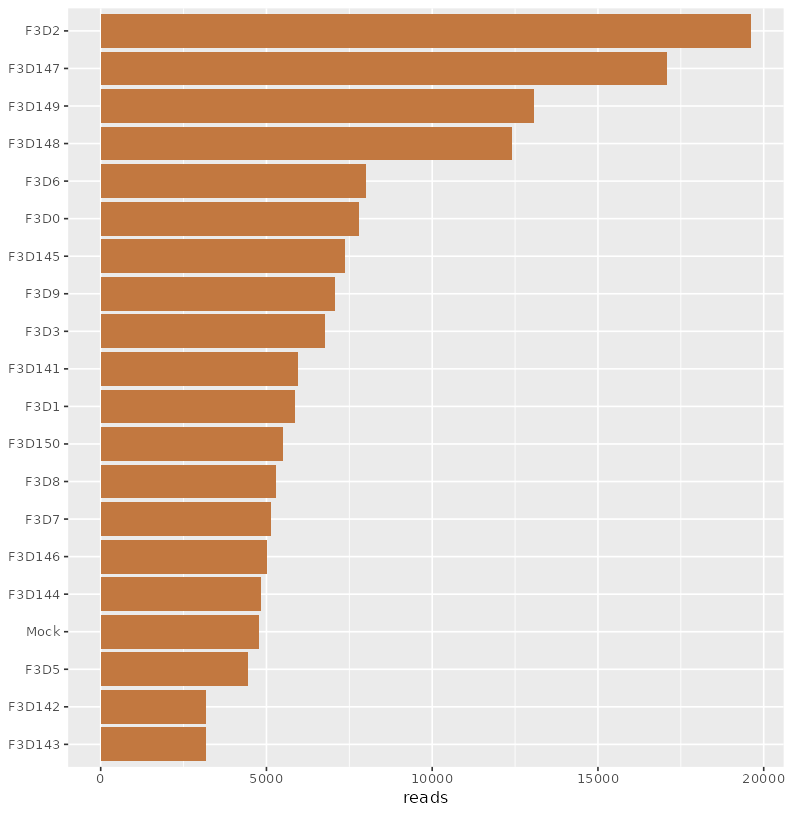

In [ ]:
step_start("n1", 1, 4, "Read Quality Report")
settings <- list(`r1_pattern` = "_R1", `r2_pattern` = "_R2", `n_reads` = 5000, `run_fastqc` = TRUE)   # this step's settings from the canvas (tested program, pinned by the platform)
# Read Quality Report: the reads as they arrive, per sample and per position.
if (!exists("mb_reads")) {
  files <- if (exists("READ_FILES") && length(READ_FILES)) READ_FILES else
    sort(list.files("data", pattern = "[.](fastq|fq)([.]gz)?$", full.names = TRUE))
  r1 <- if (length(settings$r1_pattern) && nzchar(settings$r1_pattern)) settings$r1_pattern else "_R1"
  r2 <- if (length(settings$r2_pattern) && nzchar(settings$r2_pattern)) settings$r2_pattern else "_R2"
  fwd <- files[grepl(r1, basename(files), fixed = TRUE)]
  rev <- files[grepl(r2, basename(files), fixed = TRUE)]
  if (!length(fwd)) { fwd <- files; rev <- character() }
  ids <- if (exists("df") && nrow(df)) as.character(df[[1]]) else character()
  sample_of <- function(b) {
    hit <- ids[startsWith(b, paste0(ids, "_")) | startsWith(b, paste0(ids, ".")) | startsWith(b, paste0(ids, "-"))]
    if (length(hit)) hit[which.max(nchar(hit))] else sub("[_.].*$", "", b)
  }
  mb_reads <- data.frame(sample = vapply(basename(fwd), sample_of, character(1), USE.NAMES = FALSE),
                         fwd = fwd, stringsAsFactors = FALSE)
  mb_reads$rev <- if (length(rev)) rev[match(sub(r1, r2, basename(fwd), fixed = TRUE), basename(rev))] else NA_character_
}
if (!nrow(mb_reads)) {
  step_skipped("n1", "no FASTQ files were found in the dataset")
} else {
  paired <- all(!is.na(mb_reads$rev))
  count_reads <- function(f) length(ShortRead::readFastq(f))
  mb_reads$reads <- vapply(mb_reads$fwd, count_reads, numeric(1))
  metric("n1", "samples", nrow(mb_reads))
  metric("n1", "paired_end", paired)
  metric("n1", "median_reads_per_sample", stats::median(mb_reads$reads))
  metric("n1", "min_reads_per_sample", min(mb_reads$reads))
  emit_preview("n1", data.frame(sample = mb_reads$sample, reads = mb_reads$reads,
    forward = basename(mb_reads$fwd), reverse = basename(mb_reads$rev)))
  # per-position quality from a sample of reads, the way DADA2 draws it
  n <- if (length(settings$n_reads)) settings$n_reads else 5000
  save_fig(dada2::plotQualityProfile(mb_reads$fwd, aggregate = TRUE, n = n) +
    ggplot2::ggtitle("Forward reads, all samples"), "n1__quality_forward")
  if (paired) save_fig(dada2::plotQualityProfile(mb_reads$rev, aggregate = TRUE, n = n) +
    ggplot2::ggtitle("Reverse reads, all samples"), "n1__quality_reverse")
  save_fig(ggplot2::ggplot(mb_reads, ggplot2::aes(stats::reorder(sample, reads), reads)) +
    ggplot2::geom_col(fill = "#C27840") + ggplot2::coord_flip() +
    ggplot2::labs(x = NULL, y = "reads"), "n1__reads_per_sample")
  # FastQC, the report every sequencing core sends: one HTML page per file
  if (!isFALSE(settings$run_fastqc)) {
    out <- tempfile("fastqc_"); dir.create(out)
    run_tool("fastqc", c("--outdir", out, "--quiet", "--threads", "2", mb_reads$fwd, stats::na.omit(mb_reads$rev)), node_id = "n1")
    status <- list()
    for (z in list.files(out, pattern = "_fastqc[.]zip$", full.names = TRUE)) {
      inner <- utils::unzip(z, list = TRUE)$Name
      s <- utils::read.delim(unz(z, grep("summary.txt$", inner, value = TRUE)[1]), header = FALSE, col.names = c("status", "module", "file"))
      status[[length(status) + 1]] <- s
    }
    for (h in list.files(out, pattern = "_fastqc[.]html$", full.names = TRUE)) {
      writeLines(readLines(h, warn = FALSE), file.path("artifacts", paste0("n1__", sub("[.]html$", "", basename(h)), ".html")))
    }
    if (length(status)) {
      st <- do.call(rbind, status)
      tab <- as.data.frame.matrix(table(st$module, st$status))
      tab <- data.frame(module = rownames(tab), tab, check.names = FALSE)
      metric("n1", "fastqc_modules_failed", sum(st$status == "FAIL"))
      metric("n1", "fastqc_modules_warned", sum(st$status == "WARN"))
      data.table::fwrite(tab, "artifacts/n1__fastqc_summary.csv")
    }
  }
}
step_done("n1", 1, 4, "Read Quality Report")

## Primer Trimming (Cutadapt)

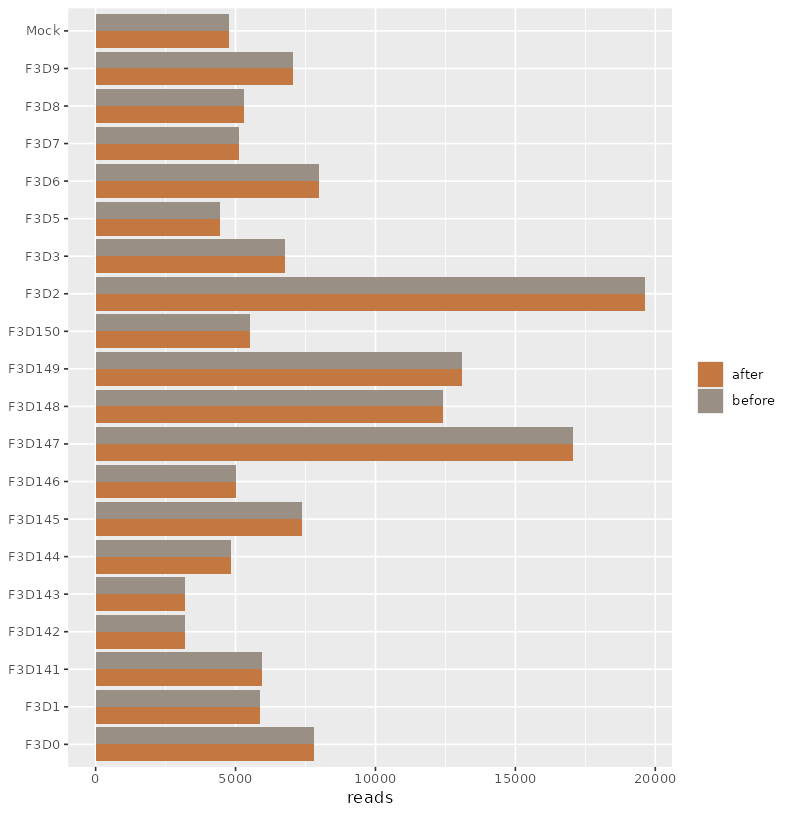

In [ ]:
step_start("n2", 2, 4, "Primer Trimming (Cutadapt)")
settings <- list(`primer_forward` = "GTGCCAGCMGCCGCGGTAA", `primer_reverse` = "GGACTACHVGGGTWTCTAAT", `error_rate` = 0.1, `min_length` = 50, `discard_untrimmed` = TRUE)   # this step's settings from the canvas (tested program, pinned by the platform)
# Primer Trimming (Cutadapt): remove the amplification primers from both ends,
# and their reverse complements where a short amplicon reads through.
if (!exists("mb_reads")) {
  files <- if (exists("READ_FILES") && length(READ_FILES)) READ_FILES else
    sort(list.files("data", pattern = "[.](fastq|fq)([.]gz)?$", full.names = TRUE))
  fwd <- files[grepl("_R1", basename(files), fixed = TRUE)]
  rev <- files[grepl("_R2", basename(files), fixed = TRUE)]
  if (!length(fwd)) { fwd <- files; rev <- character() }
  ids <- if (exists("df") && nrow(df)) as.character(df[[1]]) else character()
  sample_of <- function(b) {
    hit <- ids[startsWith(b, paste0(ids, "_")) | startsWith(b, paste0(ids, ".")) | startsWith(b, paste0(ids, "-"))]
    if (length(hit)) hit[which.max(nchar(hit))] else sub("[_.].*$", "", b)
  }
  mb_reads <- data.frame(sample = vapply(basename(fwd), sample_of, character(1), USE.NAMES = FALSE),
                         fwd = fwd, stringsAsFactors = FALSE)
  mb_reads$rev <- if (length(rev)) rev[match(sub("_R1", "_R2", basename(fwd), fixed = TRUE), basename(rev))] else NA_character_
}
fwd_primer <- toupper(gsub("\\s", "", settings$primer_forward))
rev_primer <- toupper(gsub("\\s", "", settings$primer_reverse))
if (!nzchar(fwd_primer)) {
  step_skipped("n2", "no forward primer was given")
} else {
  rc <- function(p) as.character(Biostrings::reverseComplement(Biostrings::DNAString(p)))
  paired <- all(!is.na(mb_reads$rev)) && nzchar(rev_primer)
  out <- tempfile("cutadapt_"); dir.create(out)
  rows <- list()
  trimmed <- mb_reads
  for (i in seq_len(nrow(mb_reads))) {
    f1 <- file.path(out, basename(mb_reads$fwd[i]))
    rep <- file.path(out, paste0(mb_reads$sample[i], ".json"))
    args <- c("-g", fwd_primer, "-e", as.character(settings$error_rate), "--minimum-length", as.character(settings$min_length),
              "-j", "2", "--json", rep, "-o", f1)
    if (paired) {
      f2 <- file.path(out, basename(mb_reads$rev[i]))
      args <- c(args, "-a", rc(rev_primer), "-G", rev_primer, "-A", rc(fwd_primer), "-p", f2)
    } else if (nzchar(rev_primer)) {
      args <- c(args, "-a", rc(rev_primer))
    }
    if (!isFALSE(settings$discard_untrimmed)) args <- c(args, "--discard-untrimmed")
    args <- c(args, "-n", "2", mb_reads$fwd[i], if (paired) mb_reads$rev[i])
    run_tool("cutadapt", args, node_id = if (i == 1) "n2" else NULL)
    j <- jsonlite::fromJSON(rep)
    rc_in <- j$read_counts$input
    rc_out <- j$read_counts$output
    with_primer <- j$read_counts$read1_with_adapter
    rows[[i]] <- data.frame(sample = mb_reads$sample[i], reads_in = rc_in, reads_out = rc_out,
                            with_primer = if (is.null(with_primer)) NA else with_primer)
    trimmed$fwd[i] <- f1
    if (paired) trimmed$rev[i] <- f2
  }
  tab <- do.call(rbind, rows)
  found <- sum(tab$with_primer, na.rm = TRUE) / max(sum(tab$reads_in), 1)
  # Reads that were trimmed before upload, or sequenced from past the primer,
  # carry no primer. Discarding every read without one would then discard the
  # dataset, so the step says so and the original reads go on, and what it
  # reports is what goes on, not what cutadapt would have kept.
  if (found < 0.2) {
    tab$reads_out <- tab$reads_in
    tab$note <- "no primer in the reads: passed on unchanged"
  }
  tab$kept_pct <- round(100 * tab$reads_out / pmax(tab$reads_in, 1), 1)
  metric("n2", "reads_in", sum(tab$reads_in))
  metric("n2", "reads_out", sum(tab$reads_out))
  metric("n2", "primer_found_pct", round(100 * found, 1))
  emit_preview("n2", tab)
  if (found < 0.2) {
    metric("n2", "primers_absent", TRUE)
    message("n2: the primer was found in ", round(100 * found, 1), "% of reads; the reads look already trimmed, so the original reads are used")
  } else {
    mb_raw_reads <- mb_reads
    mb_reads <- trimmed
    mb_reads <- mb_reads[file.exists(mb_reads$fwd) & tab$reads_out > 0, ]
  }
  long <- rbind(data.frame(sample = tab$sample, stage = "before", reads = tab$reads_in),
                data.frame(sample = tab$sample, stage = "after", reads = tab$reads_out))
  save_fig(ggplot2::ggplot(long, ggplot2::aes(sample, reads, fill = stage)) +
    ggplot2::geom_col(position = "dodge") + ggplot2::coord_flip() +
    ggplot2::scale_fill_manual(values = c(before = "#9A8F84", after = "#C27840")) +
    ggplot2::labs(x = NULL, y = "reads", fill = NULL), "n2__reads_before_after")
}
step_done("n2", 2, 4, "Primer Trimming (Cutadapt)")

## Filter & Trim Reads

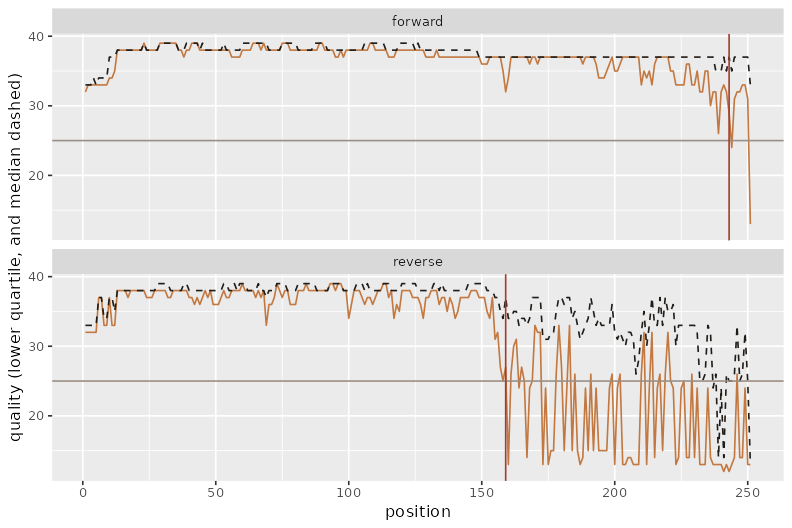

In [ ]:
step_start("n3", 3, 4, "Filter & Trim Reads")
settings <- list(`amplicon` = "16S V4", `amplicon_length` = 253, `auto_truncation` = TRUE, `quality_threshold` = 25, `min_overlap` = 20, `trunc_len_forward` = 240, `trunc_len_reverse` = 160, `max_ee_forward` = 2, `max_ee_reverse` = 2, `min_length` = 50)   # this step's settings from the canvas (tested program, pinned by the platform)
# Filter & Trim Reads: quality filtering, with the truncation lengths chosen
# from the reads' own quality profile unless they are set by hand.
if (!exists("mb_reads")) {
  files <- if (exists("READ_FILES") && length(READ_FILES)) READ_FILES else
    sort(list.files("data", pattern = "[.](fastq|fq)([.]gz)?$", full.names = TRUE))
  fwd <- files[grepl("_R1", basename(files), fixed = TRUE)]
  rev <- files[grepl("_R2", basename(files), fixed = TRUE)]
  if (!length(fwd)) { fwd <- files; rev <- character() }
  ids <- if (exists("df") && nrow(df)) as.character(df[[1]]) else character()
  sample_of <- function(b) {
    hit <- ids[startsWith(b, paste0(ids, "_")) | startsWith(b, paste0(ids, ".")) | startsWith(b, paste0(ids, "-"))]
    if (length(hit)) hit[which.max(nchar(hit))] else sub("[_.].*$", "", b)
  }
  mb_reads <- data.frame(sample = vapply(basename(fwd), sample_of, character(1), USE.NAMES = FALSE),
                         fwd = fwd, stringsAsFactors = FALSE)
  mb_reads$rev <- if (length(rev)) rev[match(sub("_R1", "_R2", basename(fwd), fixed = TRUE), basename(rev))] else NA_character_
}
paired <- all(!is.na(mb_reads$rev))
region <- settings$amplicon
amplicon_len <- switch(region, "16S V4" = 253, "16S V3-V4" = 465, "16S V4-V5" = 411, "18S V4" = 420, "18S V9" = 130,
                       "ITS" = NA, as.numeric(settings$amplicon_length))
# The quality at each position, lower quartile, from a sample of reads
q_profile <- function(files, n = 20000) {
  each <- max(200, ceiling(n / length(files)))
  qs <- lapply(files, function(f) {
    s <- ShortRead::FastqSampler(f, each); fq <- ShortRead::yield(s); close(s)
    methods::as(Biostrings::quality(fq), "matrix")
  })
  width <- max(vapply(qs, ncol, numeric(1)))
  qs <- lapply(qs, function(m) { if (ncol(m) < width) cbind(m, matrix(NA, nrow(m), width - ncol(m))) else m })
  m <- do.call(rbind, qs)
  data.frame(position = seq_len(ncol(m)), q25 = apply(m, 2, stats::quantile, 0.25, na.rm = TRUE),
             median = apply(m, 2, stats::median, na.rm = TRUE))
}
choose_len <- function(p, threshold) {
  bad <- which(p$q25 < threshold)
  if (!length(bad)) nrow(p) else max(bad[1] - 1, 50)
}
pf <- q_profile(mb_reads$fwd)
pr <- if (paired) q_profile(mb_reads$rev) else NULL
threshold <- as.numeric(settings$quality_threshold)
if (identical(region, "ITS")) {
  # ITS lengths vary between taxa: truncating to one length would remove whole taxa
  tl <- c(0, 0); how <- "none (ITS lengths vary)"
} else if (isTRUE(settings$auto_truncation)) {
  tl <- c(choose_len(pf, threshold), if (paired) choose_len(pr, threshold) else 0)
  how <- sprintf("from the quality profile (lower quartile above Q%s)", threshold)
  # paired reads must still overlap across the amplicon to be merged
  need <- if (paired && !is.na(amplicon_len)) amplicon_len + as.numeric(settings$min_overlap) else 0
  if (paired && need > 0 && sum(tl) < need) {
    short <- need - sum(tl)
    grow_f <- min(nrow(pf) - tl[1], ceiling(short / 2)); tl[1] <- tl[1] + grow_f
    tl[2] <- min(nrow(pr), tl[2] + (need - sum(tl)))
    how <- paste0(how, ", lengthened to keep a ", settings$min_overlap, "-base overlap over the ", amplicon_len, "-base amplicon")
    if (sum(tl) < need) message("n3: the reads are too short to overlap across this amplicon; merging will lose most pairs")
  }
} else {
  tl <- c(as.numeric(settings$trunc_len_forward), if (paired) as.numeric(settings$trunc_len_reverse) else 0)
  how <- "set by hand"
}
metric("n3", "trunc_len_forward", tl[1])
if (paired) metric("n3", "trunc_len_reverse", tl[2])
metric("n3", "truncation", how)
filt_dir <- tempfile("filtered_"); dir.create(filt_dir)
filt_f <- file.path(filt_dir, paste0(mb_reads$sample, "_F_filt.fastq.gz"))
filt_r <- if (paired) file.path(filt_dir, paste0(mb_reads$sample, "_R_filt.fastq.gz")) else NULL
max_ee <- c(as.numeric(settings$max_ee_forward), as.numeric(settings$max_ee_reverse))
out <- if (paired) {
  dada2::filterAndTrim(mb_reads$fwd, filt_f, mb_reads$rev, filt_r, truncLen = tl, maxN = 0, maxEE = max_ee,
                       truncQ = 2, minLen = as.numeric(settings$min_length), rm.phix = TRUE, compress = TRUE, multithread = 2)
} else {
  dada2::filterAndTrim(mb_reads$fwd, filt_f, truncLen = tl[1], maxN = 0, maxEE = max_ee[1],
                       truncQ = 2, minLen = as.numeric(settings$min_length), rm.phix = TRUE, compress = TRUE, multithread = 2)
}
mb_filter_counts <- data.frame(sample = mb_reads$sample, input = out[, 1], filtered = out[, 2])
keep <- file.exists(filt_f) & out[, 2] > 0
mb_filt <- data.frame(sample = mb_reads$sample[keep], fwd = filt_f[keep],
                      rev = if (paired) filt_r[keep] else NA_character_, stringsAsFactors = FALSE)
metric("n3", "reads_in", sum(out[, 1]))
metric("n3", "reads_kept", sum(out[, 2]))
metric("n3", "reads_kept_pct", round(100 * sum(out[, 2]) / max(sum(out[, 1]), 1), 1))
if (any(!keep)) metric("n3", "samples_emptied", paste(mb_reads$sample[!keep], collapse = ", "))
emit_preview("n3", transform(mb_filter_counts, kept_pct = round(100 * filtered / pmax(input, 1), 1)))
prof <- rbind(transform(pf, read = "forward"), if (paired) transform(pr, read = "reverse"))
cut <- data.frame(read = c("forward", if (paired) "reverse"), at = tl[seq_len(if (paired) 2 else 1)])
save_fig(ggplot2::ggplot(prof, ggplot2::aes(position, q25)) + ggplot2::geom_line(colour = "#C27840") +
  ggplot2::geom_line(ggplot2::aes(y = median), colour = "#201C18", linetype = "dashed") +
  ggplot2::geom_hline(yintercept = threshold, colour = "#9A8F84") +
  { if (all(cut$at > 0)) ggplot2::geom_vline(data = cut, ggplot2::aes(xintercept = at), colour = "#A13D2D") } +
  ggplot2::facet_wrap(~read, ncol = 1) + ggplot2::labs(y = "quality (lower quartile, and median dashed)"),
  "n3__truncation_choice")
step_done("n3", 3, 4, "Filter & Trim Reads")

## ASV Inference (DADA2)

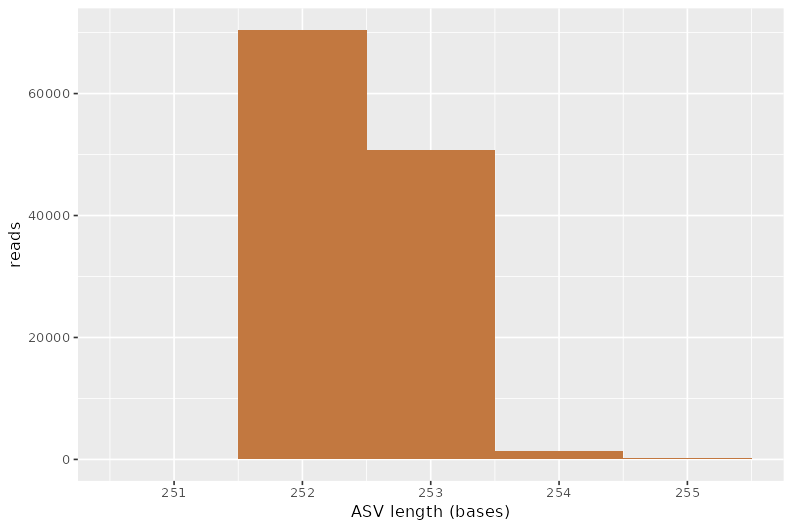

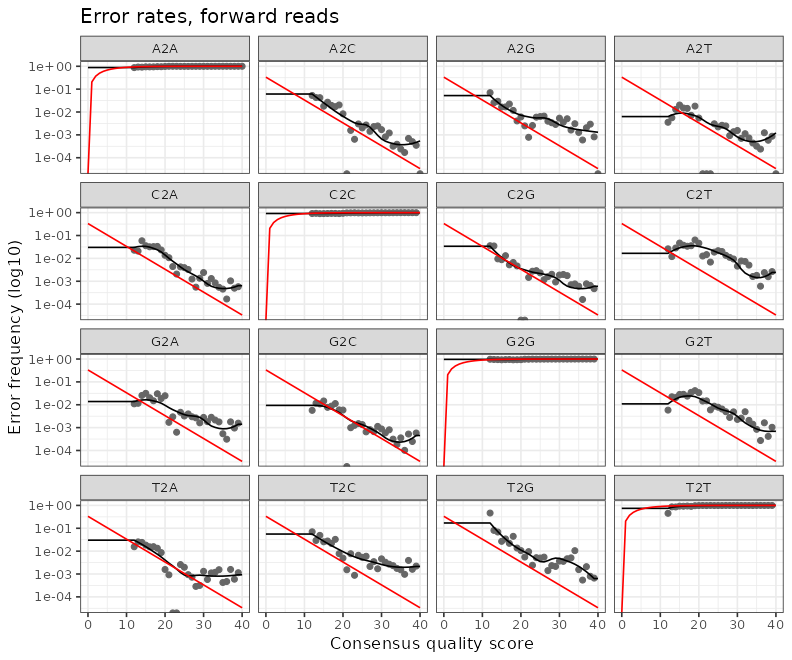

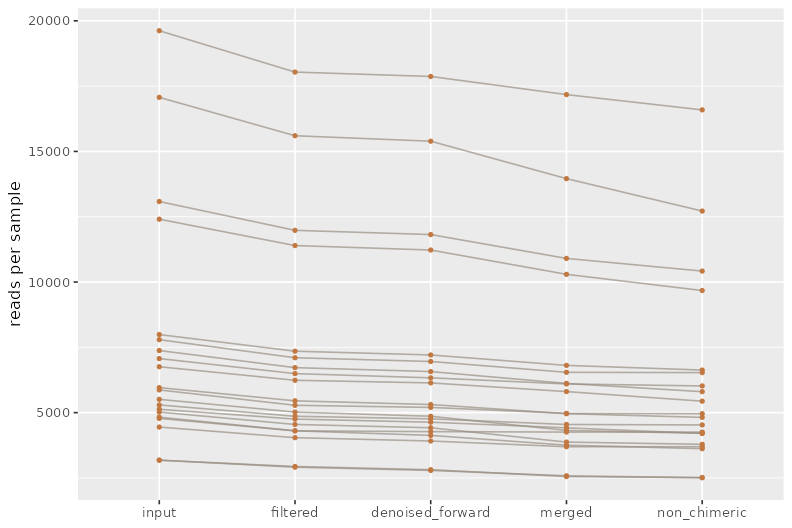

In [ ]:
step_start("n4", 4, 4, "ASV Inference (DADA2)")
settings <- list(`sample_col` = "sample", `pool` = "false", `min_overlap` = 12, `chimera_method` = "consensus", `learn_bases` = 100000000, `seed` = 100)   # this step's settings from the canvas (tested program, pinned by the platform)
# ASV Inference (DADA2): learn the run's error rates, denoise each sample into
# exact sequence variants, merge the pairs, and remove chimeras.
if (!exists("mb_filt")) {
  step_skipped("n4", "run Filter & Trim Reads first: DADA2 needs filtered reads")
} else {
  set.seed(as.integer(settings$seed))
  paired <- all(!is.na(mb_filt$rev))
  pool <- switch(settings$pool, "pseudo" = "pseudo", "true" = TRUE, FALSE)
  nbases <- as.numeric(settings$learn_bases)
  err_f <- dada2::learnErrors(mb_filt$fwd, nbases = nbases, multithread = 2, verbose = FALSE)
  dd_f <- dada2::dada(mb_filt$fwd, err = err_f, pool = pool, multithread = 2, verbose = FALSE)
  if (inherits(dd_f, "dada")) dd_f <- list(dd_f)
  names(dd_f) <- mb_filt$sample
  if (paired) {
    err_r <- dada2::learnErrors(mb_filt$rev, nbases = nbases, multithread = 2, verbose = FALSE)
    dd_r <- dada2::dada(mb_filt$rev, err = err_r, pool = pool, multithread = 2, verbose = FALSE)
    if (inherits(dd_r, "dada")) dd_r <- list(dd_r)
    names(dd_r) <- mb_filt$sample
    merged <- dada2::mergePairs(dd_f, mb_filt$fwd, dd_r, mb_filt$rev, minOverlap = as.integer(settings$min_overlap), verbose = FALSE)
    if (is.data.frame(merged)) merged <- list(merged)
    names(merged) <- mb_filt$sample
    seqtab_all <- dada2::makeSequenceTable(merged)
  } else {
    seqtab_all <- dada2::makeSequenceTable(dd_f)
  }
  seqtab <- dada2::removeBimeraDenovo(seqtab_all, method = settings$chimera_method, multithread = 2, verbose = FALSE)
  rownames(seqtab) <- mb_filt$sample
  getN <- function(x) sum(dada2::getUniques(x))
  mb_track <- data.frame(sample = mb_filt$sample,
    denoised_forward = vapply(dd_f, getN, numeric(1)),
    merged = if (paired) vapply(merged, getN, numeric(1)) else vapply(dd_f, getN, numeric(1)),
    non_chimeric = rowSums(seqtab))
  if (exists("mb_filter_counts")) mb_track <- merge(mb_filter_counts, mb_track, by = "sample", all.y = TRUE)
  # ASVs are named by abundance; the sequence stays with each name
  ord <- order(-colSums(seqtab))
  seqtab <- seqtab[, ord, drop = FALSE]
  asv_seqs <- Biostrings::DNAStringSet(colnames(seqtab))
  names(asv_seqs) <- paste0("ASV", seq_along(asv_seqs))
  colnames(seqtab) <- names(asv_seqs)
  meta <- if (exists("df") && nrow(df)) df else data.frame(sample = rownames(seqtab))
  scol <- settings$sample_col
  if (!length(scol) || !nzchar(scol) || !(scol %in% names(meta))) {
    scol <- names(meta)[which.max(vapply(meta, function(v) sum(as.character(v) %in% rownames(seqtab)), numeric(1)))]
  }
  meta <- meta[!duplicated(meta[[scol]]), , drop = FALSE]
  rownames(meta) <- as.character(meta[[scol]])
  meta <- meta[rownames(seqtab), , drop = FALSE]
  rownames(meta) <- rownames(seqtab)
  meta[[scol]] <- rownames(seqtab)
  ps <- phyloseq::phyloseq(phyloseq::otu_table(seqtab, taxa_are_rows = FALSE),
                           phyloseq::sample_data(meta), phyloseq::refseq(asv_seqs))
  mb_sample_col <- scol
  metric("n4", "asvs", ncol(seqtab))
  metric("n4", "samples", nrow(seqtab))
  metric("n4", "reads_non_chimeric", sum(seqtab))
  metric("n4", "chimeric_reads_pct", round(100 * (1 - sum(seqtab) / max(sum(seqtab_all), 1)), 2))
  if ("input" %in% names(mb_track)) metric("n4", "reads_retained_pct", round(100 * sum(mb_track$non_chimeric) / max(sum(mb_track$input), 1), 1))
  emit_preview("n4", mb_track)
  save_fig(dada2::plotErrors(err_f, nominalQ = TRUE) + ggplot2::ggtitle("Error rates, forward reads"), "n4__error_rates", height = 6)
  lens <- data.frame(length = Biostrings::width(asv_seqs), reads = colSums(seqtab))
  save_fig(ggplot2::ggplot(lens, ggplot2::aes(length, weight = reads)) + ggplot2::geom_histogram(binwidth = 1, fill = "#C27840") +
    ggplot2::labs(x = "ASV length (bases)", y = "reads"), "n4__asv_lengths")
  long <- stats::reshape(mb_track, direction = "long", varying = setdiff(names(mb_track), "sample"),
                         v.names = "reads", timevar = "stage", times = setdiff(names(mb_track), "sample"), idvar = "sample")
  long$stage <- factor(long$stage, levels = setdiff(names(mb_track), "sample"))
  save_fig(ggplot2::ggplot(long, ggplot2::aes(stage, reads, group = sample)) + ggplot2::geom_line(colour = "#9A8F84", alpha = 0.7) +
    ggplot2::geom_point(colour = "#C27840", size = 1) + ggplot2::labs(x = NULL, y = "reads per sample"), "n4__reads_through_the_steps")
  # The denoising objects hold every read's assignment and are not needed
  # after this step; kept, they cost PICRUSt2 the memory it needs later.
  rm(list = intersect(c("dd_f", "dd_r", "merged", "seqtab_all"), ls())); invisible(gc())
}
step_done("n4", 4, 4, "ASV Inference (DADA2)")

## Taxonomy Assignment (bio_expr)

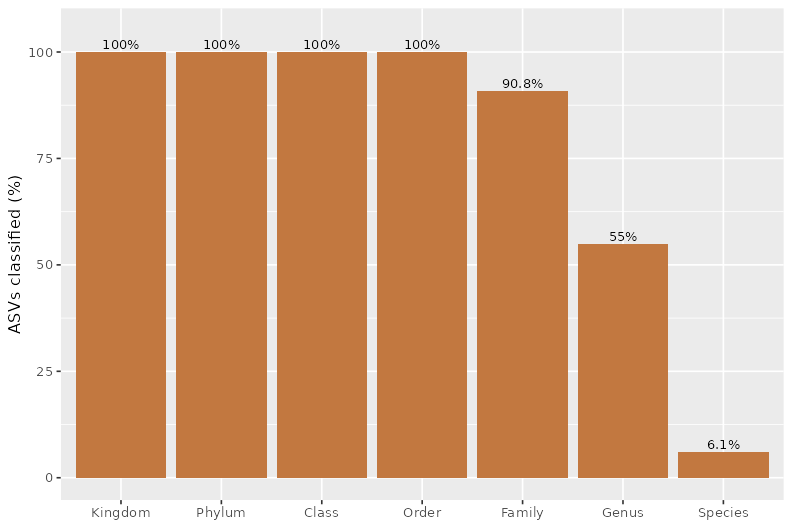

In [ ]:
step_start("n5", 6, 15, "Taxonomy Assignment (bio_expr)")
settings <- list(`reference` = "SILVA 138.1 (16S)", `min_bootstrap` = 50, `species` = TRUE)   # this step's settings from the canvas (tested program, pinned by the platform)
# Taxonomy Assignment: the naive Bayesian classifier (the RDP method, as DADA2
# implements it) against a curated reference, and exact species matches for 16S.
if (!exists("ps") || is.null(ps)) {
  step_skipped("n5", "run ASV Inference (DADA2) or Import Feature Table first")
} else if (is.null(phyloseq::refseq(ps, errorIfNULL = FALSE))) {
  step_skipped("n5", "the feature table carries no ASV sequences to classify")
} else {
  refdir <- "/opt/alkhemyst/refs/microbiome"
  ref <- switch(settings$reference,
    "PR2 5.0.0 (18S)" = list(file = "pr2_version_5.0.0_SSU_dada2.fasta.gz", species = NULL, rc = FALSE,
      levels = c("Domain", "Supergroup", "Division", "Subdivision", "Class", "Order", "Family", "Genus", "Species")),
    "UNITE 10.0 (ITS, fungi)" = list(file = "unite_fungi_v10.0.fasta", species = NULL, rc = TRUE,
      levels = c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species")),
    list(file = "silva_nr99_v138.1_train_set.fa.gz", species = "silva_species_assignment_v138.1.fa.gz", rc = FALSE,
      levels = c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus")))
  seqs <- as.character(phyloseq::refseq(ps))
  set.seed(100)
  taxa <- dada2::assignTaxonomy(seqs, file.path(refdir, ref$file), minBoot = as.integer(settings$min_bootstrap),
                                taxLevels = ref$levels, tryRC = ref$rc, multithread = 2, verbose = FALSE)
  if (!is.null(ref$species) && !isFALSE(settings$species)) {
    taxa <- dada2::addSpecies(taxa, file.path(refdir, ref$species), verbose = FALSE)
  }
  # UNITE labels ranks as "k__Fungi"; the prefix says nothing the column does not
  taxa[] <- sub("^[a-z]__", "", taxa)
  rownames(taxa) <- names(seqs)
  ps <- phyloseq::merge_phyloseq(ps, phyloseq::tax_table(taxa))
  manifest <- tryCatch(utils::read.delim(file.path(refdir, "MANIFEST.tsv")), error = function(e) NULL)
  used <- if (!is.null(manifest)) manifest$version[manifest$file == ref$file] else ref$file
  metric("n5", "reference", if (length(used)) used[1] else ref$file)
  rates <- data.frame(rank = colnames(taxa), classified_pct = round(100 * colMeans(!is.na(taxa)), 1))
  for (i in seq_len(nrow(rates))) metric("n5", paste0("classified_", tolower(rates$rank[i]), "_pct"), rates$classified_pct[i])
  emit_preview("n5", data.frame(asv = rownames(taxa), taxa, check.names = FALSE, row.names = NULL))
  data.table::fwrite(data.frame(asv = rownames(taxa), sequence = seqs, taxa, check.names = FALSE), "artifacts/n5__taxonomy.csv")
  rates$rank <- factor(rates$rank, levels = colnames(taxa))
  save_fig(ggplot2::ggplot(rates, ggplot2::aes(rank, classified_pct)) + ggplot2::geom_col(fill = "#C27840") +
    ggplot2::geom_text(ggplot2::aes(label = paste0(classified_pct, "%")), vjust = -0.3, size = 3) +
    ggplot2::labs(x = NULL, y = "ASVs classified (%)") + ggplot2::ylim(0, 105), "n5__classified_by_rank")
}
step_done("n5", 6, 15, "Taxonomy Assignment (bio_expr)")

## Phylogenetic Tree

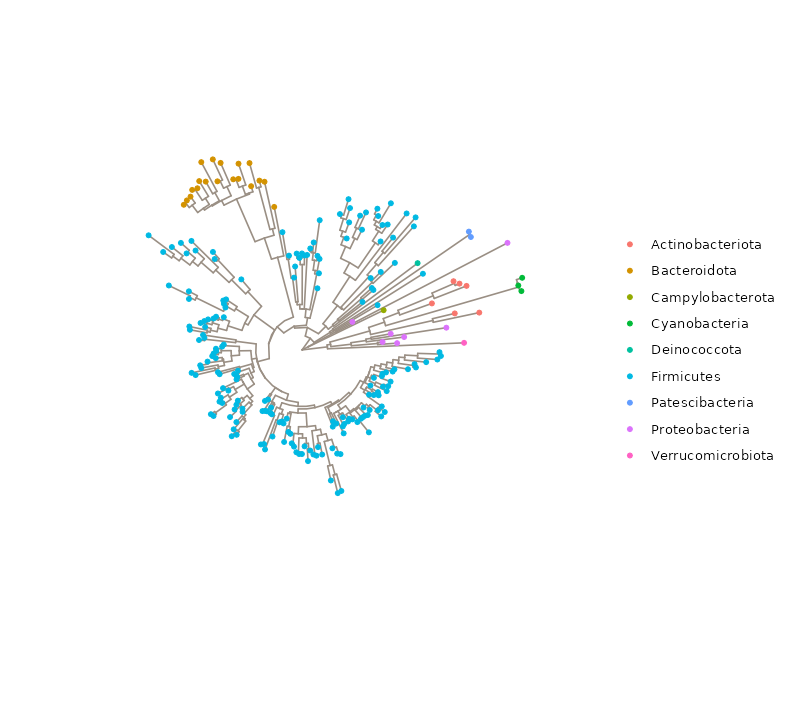

In [ ]:
step_start("n6", 6, 15, "Phylogenetic Tree")
settings <- list(`model` = "GTR")   # this step's settings from the canvas (tested program, pinned by the platform)
# Phylogenetic Tree: align the ASVs with MAFFT and infer an approximately
# maximum-likelihood tree with FastTree (GTR model), rooted at its midpoint.
if (!exists("ps") || is.null(ps) || is.null(phyloseq::refseq(ps, errorIfNULL = FALSE))) {
  step_skipped("n6", "run ASV Inference (DADA2) first: the tree is built from the ASV sequences")
} else if (phyloseq::ntaxa(ps) < 3) {
  step_skipped("n6", "fewer than three ASVs: there is no tree to build")
} else {
  fa <- tempfile(fileext = ".fasta"); aln <- tempfile(fileext = ".aln"); nwk <- tempfile(fileext = ".nwk")
  Biostrings::writeXStringSet(phyloseq::refseq(ps), fa)
  run_tool("mafft", c("--auto", "--thread", "2", "--quiet", fa), node_id = "n6", stdout_file = aln)
  run_tool("FastTree", c("-nt", if (identical(settings$model, "GTR")) "-gtr", "-gamma", "-quiet", aln), stdout_file = nwk)
  tree <- ape::read.tree(nwk)
  tree <- phangorn::midpoint(tree)
  ps <- phyloseq::merge_phyloseq(ps, phyloseq::phy_tree(tree))
  mb_tree <- tree
  ape::write.tree(tree, "artifacts/n6__asv_tree.nwk")
  metric("n6", "tips", ape::Ntip(tree))
  metric("n6", "alignment_columns", unique(Biostrings::width(Biostrings::readDNAStringSet(aln)))[1])
  tips <- data.frame(label = tree$tip.label)
  if (!is.null(phyloseq::tax_table(ps, errorIfNULL = FALSE))) {
    tt <- as.data.frame(as(phyloseq::tax_table(ps), "matrix"))
    tips$group <- ifelse(is.na(tt[tips$label, 2]), "Unclassified", tt[tips$label, 2])
  } else tips$group <- "ASV"
  p <- ggtree::`%<+%`(ggtree::ggtree(tree, layout = "circular", colour = "#9A8F84"), tips) +
    ggtree::geom_tippoint(ggplot2::aes(colour = group), size = 1.2) + ggplot2::labs(colour = NULL)
  save_fig(p, "n6__tree", width = 7.2, height = 6.4)
  emit_preview("n6", data.frame(asv = tree$tip.label, group = tips$group))
}
step_done("n6", 6, 15, "Phylogenetic Tree")

## BIOM Export (bio_expr)

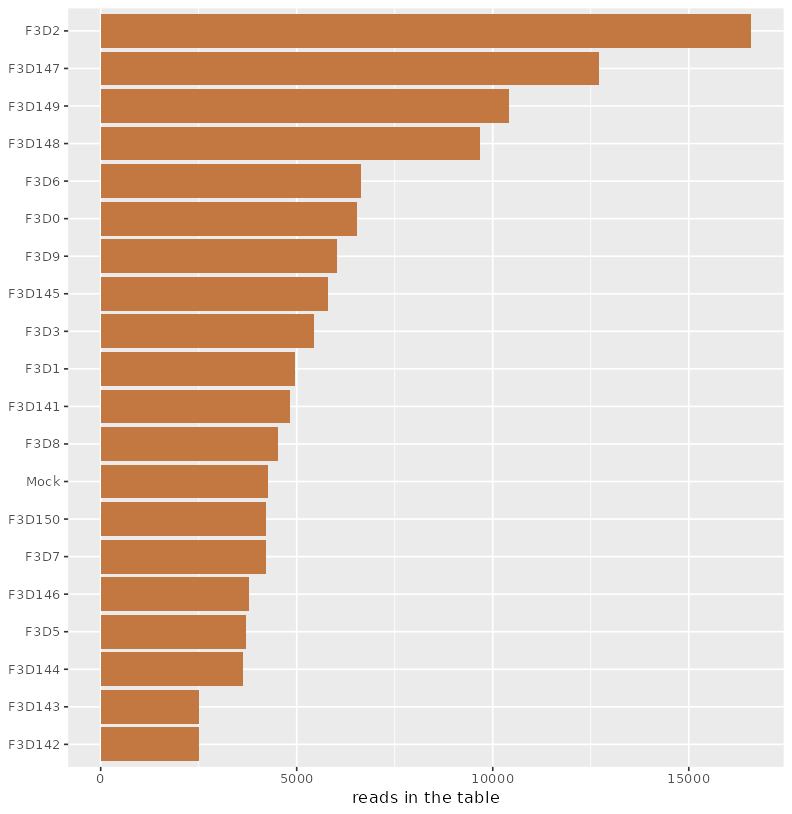

In [ ]:
step_start("n7", 9, 15, "BIOM Export (bio_expr)")
settings <- list(`include_taxonomy` = TRUE, `include_samples` = TRUE)   # this step's settings from the canvas (tested program, pinned by the platform)
# BIOM Export: the feature table in the BIOM format every microbiome tool
# reads (QIIME 2, phyloseq, MicrobiomeAnalyst), with its taxonomy, sample
# table, sequences and tree beside it.
if (!exists("ps") || is.null(ps)) {
  step_skipped("n7", "there is no feature table yet: run ASV Inference (DADA2) or Import Feature Table first")
} else {
  otu <- as(phyloseq::otu_table(ps), "matrix")
  if (!phyloseq::taxa_are_rows(ps)) otu <- t(otu)
  tax <- if (!is.null(phyloseq::tax_table(ps, errorIfNULL = FALSE))) as.data.frame(as(phyloseq::tax_table(ps), "matrix")) else NULL
  sam <- if (!is.null(phyloseq::sample_data(ps, errorIfNULL = FALSE))) data.frame(phyloseq::sample_data(ps), check.names = FALSE) else NULL
  # BIOM 1.0 (JSON), written here rather than by biomformat::write_biom, which
  # puts each sample's metadata and each feature's taxonomy out as a bare array.
  # The Python biom reader behind QIIME 2 and PICRUSt2 refuses that ("Unable to
  # cast metadata"); the format wants a map per sample and {"taxonomy": [...]}.
  taxm <- if (!is.null(tax) && !isFALSE(settings$include_taxonomy)) as.matrix(tax) else NULL
  samm <- if (!is.null(sam) && !isFALSE(settings$include_samples)) sam else NULL
  nz <- which(otu != 0, arr.ind = TRUE)
  biom <- list(
    id = "n7 feature table", format = "Biological Observation Matrix 1.0.0", format_url = "http://biom-format.org",
    type = "OTU table", generated_by = "AlkhemYst-Ai", date = format(Sys.time(), "%Y-%m-%dT%H:%M:%S"),
    matrix_type = "sparse", matrix_element_type = if (all(otu == round(otu))) "int" else "float",
    shape = dim(otu), data = unname(cbind(nz[, 1] - 1, nz[, 2] - 1, otu[nz])),
    rows = lapply(rownames(otu), function(f) list(id = f, metadata = if (is.null(taxm)) NULL else
      list(taxonomy = I(ifelse(is.na(taxm[f, ]), "", unname(taxm[f, ])))))),
    columns = lapply(colnames(otu), function(s) list(id = s, metadata = if (is.null(samm)) NULL else
      lapply(as.list(samm[s, , drop = FALSE]), function(v) if (is.na(v)) NULL else as.character(v)))))
  jsonlite::write_json(biom, "artifacts/n7__feature_table.biom", auto_unbox = TRUE, null = "null", na = "null", digits = NA)
  data.table::fwrite(data.frame(feature = rownames(otu), otu, check.names = FALSE), "artifacts/n7__feature_table.csv")
  if (!is.null(tax)) data.table::fwrite(data.frame(feature = rownames(tax), tax, check.names = FALSE), "artifacts/n7__taxonomy.csv")
  if (!is.null(sam)) data.table::fwrite(sam, "artifacts/n7__sample_table.csv")
  if (!is.null(phyloseq::refseq(ps, errorIfNULL = FALSE))) Biostrings::writeXStringSet(phyloseq::refseq(ps), "artifacts/n7__sequences.fasta")
  if (!is.null(phyloseq::phy_tree(ps, errorIfNULL = FALSE))) ape::write.tree(phyloseq::phy_tree(ps), "artifacts/n7__tree.nwk")
  metric("n7", "features", nrow(otu))
  metric("n7", "samples", ncol(otu))
  metric("n7", "total_reads", sum(otu))
  emit_preview("n7", data.frame(feature = rownames(otu), otu[, seq_len(min(ncol(otu), 12)), drop = FALSE], check.names = FALSE))
  depth <- data.frame(sample = colnames(otu), reads = colSums(otu))
  save_fig(ggplot2::ggplot(depth, ggplot2::aes(stats::reorder(sample, reads), reads)) + ggplot2::geom_col(fill = "#C27840") +
    ggplot2::coord_flip() + ggplot2::labs(x = NULL, y = "reads in the table"), "n7__reads_per_sample")
}
step_done("n7", 9, 15, "BIOM Export (bio_expr)")

## Taxonomy Composition (bio_expr)

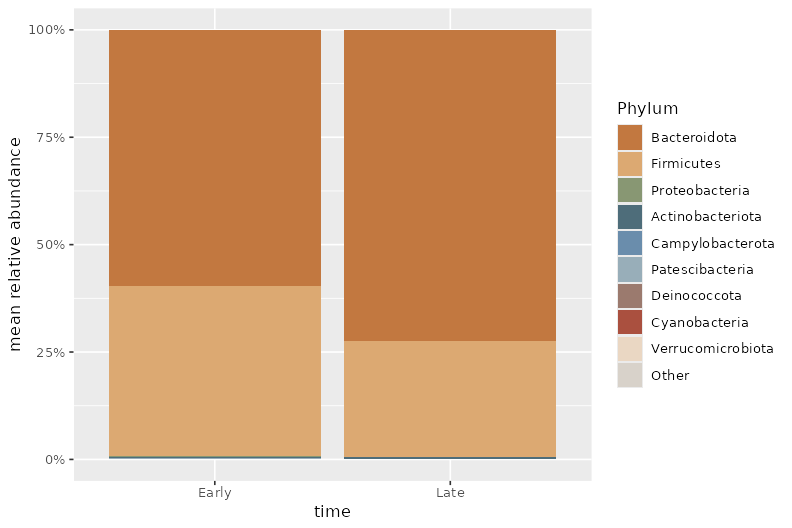

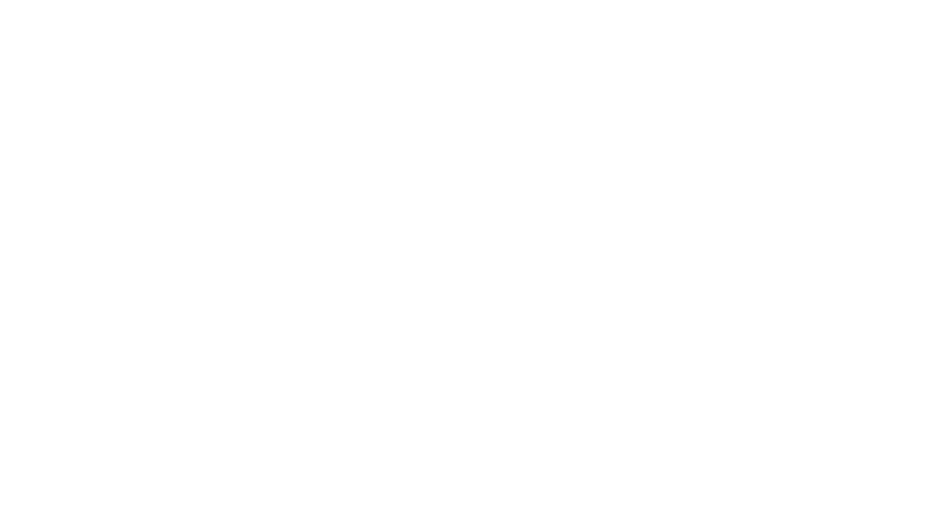

In [ ]:
step_start("n9", 10, 15, "Taxonomy Composition (bio_expr)")
settings <- list(`rank` = "Phylum", `top_n` = 10, `group_col` = "time")   # this step's settings from the canvas (tested program, pinned by the platform)
# Taxonomy Composition: relative abundance at a chosen rank, the most abundant
# taxa named and the rest pooled, per sample and per group.
if (!exists("ps") || is.null(ps) || is.null(phyloseq::tax_table(ps, errorIfNULL = FALSE))) {
  step_skipped("n9", "the feature table has no taxonomy: run Taxonomy Assignment first")
} else {
  rank <- settings$rank
  if (!(rank %in% phyloseq::rank_names(ps))) rank <- phyloseq::rank_names(ps)[min(2, length(phyloseq::rank_names(ps)))]
  otu <- as(phyloseq::otu_table(ps), "matrix"); if (phyloseq::taxa_are_rows(ps)) otu <- t(otu)
  tax <- as(phyloseq::tax_table(ps), "matrix")[colnames(otu), rank]
  tax[is.na(tax) | tax == ""] <- "Unclassified"
  agg <- t(rowsum(t(otu), tax))
  rel <- agg / pmax(rowSums(agg), 1)
  top <- names(sort(colMeans(rel), decreasing = TRUE))[seq_len(min(as.integer(settings$top_n), ncol(rel)))]
  other <- setdiff(colnames(rel), top)
  shown <- cbind(rel[, top, drop = FALSE], Other = if (length(other)) rowSums(rel[, other, drop = FALSE]) else 0)
  long <- data.frame(sample = rep(rownames(shown), ncol(shown)), taxon = rep(colnames(shown), each = nrow(shown)),
                     abundance = as.vector(shown))
  long$taxon <- factor(long$taxon, levels = c(top, "Other"))
  grp <- settings$group_col
  sam <- if (!is.null(phyloseq::sample_data(ps, errorIfNULL = FALSE))) data.frame(phyloseq::sample_data(ps), check.names = FALSE) else NULL
  has_grp <- !is.null(sam) && length(grp) && nzchar(grp) && grp %in% names(sam)
  pal <- grDevices::colorRampPalette(c("#C27840", "#E0B07A", "#6B8F71", "#3D5A80", "#98C1D9", "#9A8F84", "#A13D2D", "#EAD7C3"))(length(top))
  pal <- c(stats::setNames(pal, top), Other = "#D8D2CA")
  p <- ggplot2::ggplot(long, ggplot2::aes(sample, abundance, fill = taxon)) + ggplot2::geom_col(width = 0.9) +
    ggplot2::scale_fill_manual(values = pal) + ggplot2::scale_y_continuous(labels = function(x) paste0(100 * x, "%")) +
    ggplot2::labs(x = NULL, y = paste("relative abundance,", rank), fill = rank) +
    ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5))
  if (has_grp) {
    long$group <- as.character(sam[long$sample, grp]); long$group[is.na(long$group) | long$group == ""] <- "(none)"
    p <- p + ggplot2::facet_grid(~group, scales = "free_x", space = "free_x")
    # a sample with no group (a mock community, a blank) is drawn per sample
    # above and left out of the group means, where it would read as a group
    means <- stats::aggregate(abundance ~ group + taxon, data = long[long$group != "(none)", ], FUN = mean)
    save_fig(ggplot2::ggplot(means, ggplot2::aes(group, abundance, fill = taxon)) + ggplot2::geom_col() +
      ggplot2::scale_fill_manual(values = pal) + ggplot2::scale_y_continuous(labels = function(x) paste0(100 * x, "%")) +
      ggplot2::labs(x = grp, y = "mean relative abundance", fill = rank), "n9__composition_by_group")
  }
  save_fig(p, "n9__composition_by_sample", width = max(7.2, 0.28 * nrow(shown) + 3))
  metric("n9", "rank", rank)
  metric("n9", "taxa_at_rank", ncol(rel))
  metric("n9", "top_taxon", top[1])
  metric("n9", "top_taxon_mean_pct", round(100 * mean(rel[, top[1]]), 1))
  data.table::fwrite(data.frame(sample = rownames(rel), rel, check.names = FALSE), "artifacts/n9__relative_abundance.csv")
  emit_preview("n9", data.frame(taxon = colnames(shown), mean_pct = round(100 * colMeans(shown), 2)))
}
step_done("n9", 10, 15, "Taxonomy Composition (bio_expr)")

## Alpha Diversity

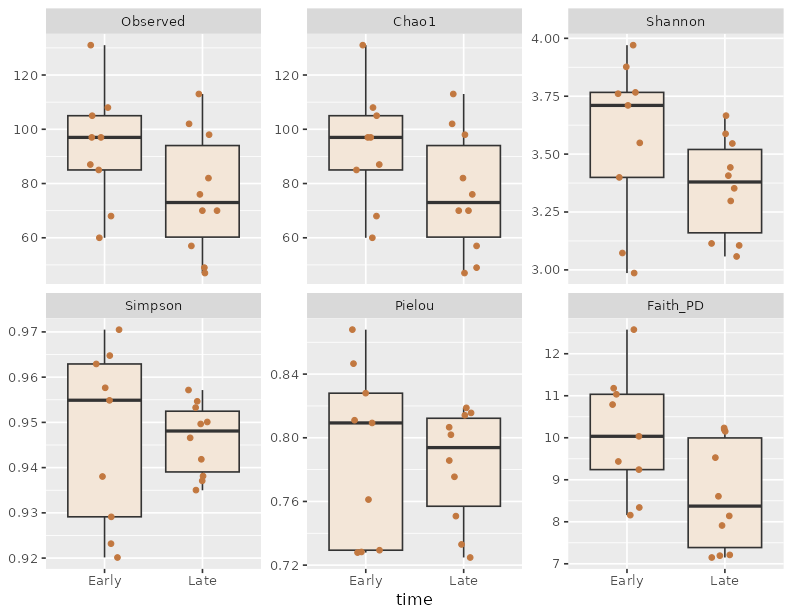

In [ ]:
step_start("n10", 11, 15, "Alpha Diversity")
settings <- list(`group_col` = "time", `rarefy` = FALSE, `rarefy_depth` = 0, `seed` = 1)   # this step's settings from the canvas (tested program, pinned by the platform)
# Alpha Diversity: richness and evenness within each sample, compared between groups.
if (!exists("ps") || is.null(ps)) {
  step_skipped("n10", "there is no feature table yet")
} else {
  x <- ps
  if (isTRUE(settings$rarefy)) {
    depth <- if (as.numeric(settings$rarefy_depth) > 0) as.numeric(settings$rarefy_depth) else min(phyloseq::sample_sums(x))
    x <- phyloseq::rarefy_even_depth(x, sample.size = depth, rngseed = as.integer(settings$seed), verbose = FALSE)
    metric("n10", "rarefied_to", depth)
  }
  est <- phyloseq::estimate_richness(x, measures = c("Observed", "Chao1", "Shannon", "Simpson"))
  rownames(est) <- phyloseq::sample_names(x)
  est$Pielou <- est$Shannon / log(pmax(est$Observed, 2))
  tree <- phyloseq::phy_tree(x, errorIfNULL = FALSE)
  if (!is.null(tree)) {
    otu <- as(phyloseq::otu_table(x), "matrix"); if (phyloseq::taxa_are_rows(x)) otu <- t(otu)
    est$Faith_PD <- picante::pd(otu, tree, include.root = FALSE)[rownames(est), "PD"]
  } else metric("n10", "faith_pd", "not computed: no phylogenetic tree (run Phylogenetic Tree first)")
  keep <- intersect(c("Observed", "Chao1", "Shannon", "Simpson", "Pielou", "Faith_PD"), names(est))
  est <- est[, keep, drop = FALSE]
  table_out <- data.frame(sample = rownames(est), round(est, 4), check.names = FALSE)
  grp <- settings$group_col
  sam <- if (!is.null(phyloseq::sample_data(x, errorIfNULL = FALSE))) data.frame(phyloseq::sample_data(x), check.names = FALSE) else NULL
  if (!is.null(sam) && length(grp) && nzchar(grp) && grp %in% names(sam)) {
    g <- as.character(sam[rownames(est), grp]); ok <- !is.na(g) & g != ""
    table_out[[grp]] <- g
    long <- data.frame(metric = rep(keep, each = sum(ok)), group = rep(g[ok], length(keep)),
                       value = unlist(lapply(keep, function(k) est[ok, k])))
    long$metric <- factor(long$metric, levels = keep)
    if (length(unique(g[ok])) >= 2) {
      for (k in keep) {
        kt <- stats::kruskal.test(est[ok, k], factor(g[ok]))
        metric("n10", paste0(k, "_p"), signif(kt$p.value, 3))
      }
      if (length(unique(g[ok])) > 2) {
        pw <- stats::pairwise.wilcox.test(est[ok, "Shannon"], g[ok], p.adjust.method = "BH")
        metric("n10", "Shannon_pairwise_min_p", signif(min(pw$p.value, na.rm = TRUE), 3))
      }
    }
    save_fig(ggplot2::ggplot(long, ggplot2::aes(group, value)) + ggplot2::geom_boxplot(outlier.shape = NA, fill = "#F3E6D8") +
      ggplot2::geom_jitter(width = 0.15, colour = "#C27840", size = 1.4) + ggplot2::facet_wrap(~metric, scales = "free_y") +
      ggplot2::labs(x = grp, y = NULL), "n10__alpha_by_group", height = 5.6)
  } else {
    long <- data.frame(metric = rep(keep, each = nrow(est)), value = unlist(est[keep]))
    save_fig(ggplot2::ggplot(long, ggplot2::aes(value)) + ggplot2::geom_histogram(bins = 15, fill = "#C27840") +
      ggplot2::facet_wrap(~metric, scales = "free"), "n10__alpha_distributions")
  }
  for (k in keep) metric("n10", paste0(k, "_median"), round(stats::median(est[[k]]), 3))
  emit_preview("n10", table_out)
  data.table::fwrite(table_out, "artifacts/n10__alpha_diversity.csv")
}
step_done("n10", 11, 15, "Alpha Diversity")

## Beta Diversity

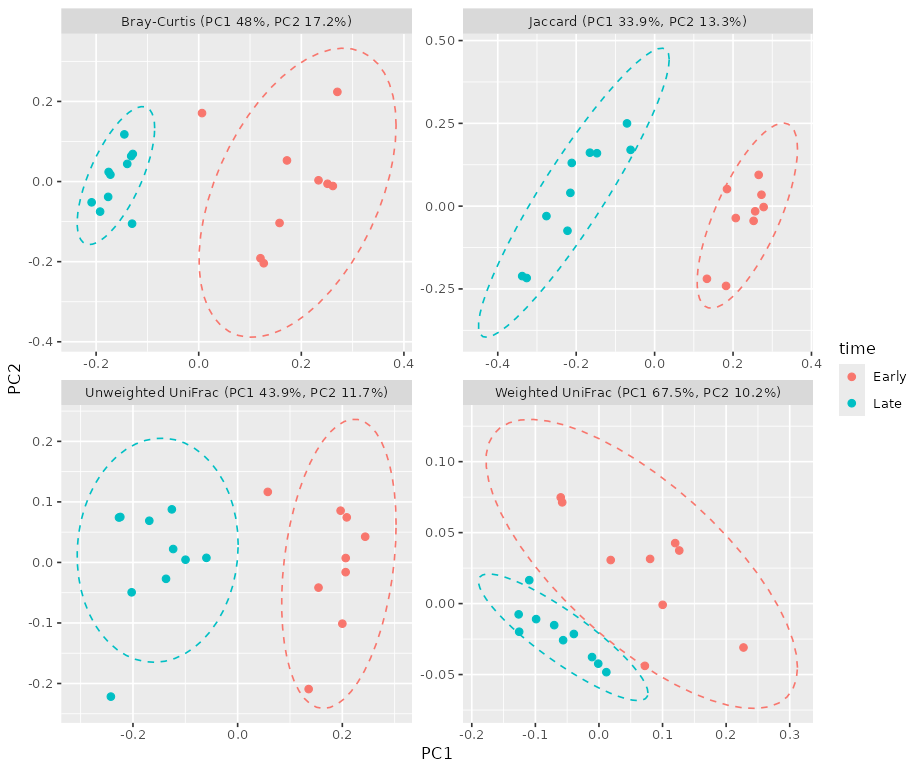

In [ ]:
step_start("n11", 12, 15, "Beta Diversity")
settings <- list(`distances` = c("Bray-Curtis", "Jaccard", "Unweighted UniFrac", "Weighted UniFrac"), `group_col` = "time", `permutations` = 999, `seed` = 1)   # this step's settings from the canvas (tested program, pinned by the platform)
# Beta Diversity: how different the samples are from each other, drawn as a
# PCoA for each distance and tested between groups with PERMANOVA.
if (!exists("ps") || is.null(ps)) {
  step_skipped("n11", "there is no feature table yet")
} else {
  x <- phyloseq::prune_samples(phyloseq::sample_sums(ps) > 0, ps)
  grp <- settings$group_col
  sam <- if (!is.null(phyloseq::sample_data(x, errorIfNULL = FALSE))) data.frame(phyloseq::sample_data(x), check.names = FALSE) else NULL
  has_grp <- !is.null(sam) && length(grp) && nzchar(grp) && grp %in% names(sam)
  # Compared by group, the ordination shows the samples the test compares. A
  # sample with no group (a mock community, a blank) is left out, and named:
  # kept, the MiSeq SOP mock took the whole first axis of the Bray-Curtis PCoA.
  if (has_grp) {
    gv <- as.character(sam[phyloseq::sample_names(x), grp])
    out <- phyloseq::sample_names(x)[is.na(gv) | gv == ""]
    if (length(out) && length(out) < phyloseq::nsamples(x) - 3) {
      x <- phyloseq::prune_samples(setdiff(phyloseq::sample_names(x), out), x)
      metric("n11", "samples_without_group_left_out", paste(out, collapse = ", "))
    }
  }
  rel <- phyloseq::transform_sample_counts(x, function(v) v / sum(v))
  otu <- as(phyloseq::otu_table(rel), "matrix"); if (phyloseq::taxa_are_rows(rel)) otu <- t(otu)
  tree <- phyloseq::phy_tree(x, errorIfNULL = FALSE)
  wanted <- trimws(unlist(strsplit(as.character(unlist(settings$distances)), ",")))
  dists <- list()
  if ("Bray-Curtis" %in% wanted) dists[["Bray-Curtis"]] <- vegan::vegdist(otu, "bray")
  if ("Jaccard" %in% wanted) dists[["Jaccard"]] <- vegan::vegdist(otu > 0, "jaccard", binary = TRUE)
  if (!is.null(tree) && "Unweighted UniFrac" %in% wanted) dists[["Unweighted UniFrac"]] <- phyloseq::UniFrac(x, weighted = FALSE)
  if (!is.null(tree) && "Weighted UniFrac" %in% wanted) dists[["Weighted UniFrac"]] <- phyloseq::UniFrac(x, weighted = TRUE)
  if (is.null(tree) && any(grepl("UniFrac", wanted))) metric("n11", "unifrac", "not computed: no phylogenetic tree (run Phylogenetic Tree first)")
  pts <- list(); tests <- list()
  for (nm in names(dists)) {
    d <- dists[[nm]]
    pc <- stats::cmdscale(d, k = 2, eig = TRUE)
    ev <- pc$eig[pc$eig > 0]; pct <- round(100 * pc$eig[1:2] / sum(ev), 1)
    pts[[nm]] <- data.frame(sample = rownames(pc$points), PC1 = pc$points[, 1], PC2 = pc$points[, 2],
                            distance = sprintf("%s (PC1 %s%%, PC2 %s%%)", nm, pct[1], pct[2]))
    if (has_grp) {
      g <- as.character(sam[labels(d), grp]); ok <- !is.na(g) & g != ""
      if (length(unique(g[ok])) >= 2 && sum(ok) >= 4) {
        dd <- stats::as.dist(as.matrix(d)[ok, ok])
        md <- data.frame(group = factor(g[ok]))
        set.seed(as.integer(settings$seed))
        a <- vegan::adonis2(dd ~ group, data = md, permutations = as.integer(settings$permutations))
        disp <- vegan::betadisper(dd, md$group)
        bd <- vegan::permutest(disp, permutations = as.integer(settings$permutations))
        # which group varies more: its samples' mean distance to the group centroid
        spread <- tapply(disp$distances, disp$group, mean)
        spread_txt <- paste(sprintf("%s %.3f", names(spread), spread), collapse = "; ")
        tests[[nm]] <- data.frame(distance = nm, R2 = round(a$R2[1], 4), F = round(a$F[1], 3), p = a$`Pr(>F)`[1],
                                  dispersion_p = bd$tab$`Pr(>F)`[1], spread_by_group = spread_txt)
        key <- gsub("[^a-z]+", "_", tolower(nm))
        metric("n11", paste0(key, "_permanova_R2"), round(a$R2[1], 4))
        metric("n11", paste0(key, "_permanova_p"), a$`Pr(>F)`[1])
        metric("n11", paste0(key, "_dispersion_p"), bd$tab$`Pr(>F)`[1])
        metric("n11", paste0(key, "_spread_by_group"), spread_txt)
      }
    }
  }
  allp <- do.call(rbind, pts)
  if (has_grp) { allp$group <- as.character(sam[allp$sample, grp]); allp$group[is.na(allp$group) | allp$group == ""] <- "(none)" } else allp$group <- "all"
  p <- ggplot2::ggplot(allp, ggplot2::aes(PC1, PC2, colour = group)) + ggplot2::geom_point(size = 2) +
    ggplot2::facet_wrap(~distance, scales = "free") + ggplot2::labs(colour = if (has_grp) grp else NULL)
  if (has_grp) p <- p + ggplot2::stat_ellipse(data = allp[allp$group != "(none)", ], level = 0.95, linetype = "dashed", show.legend = FALSE)
  save_fig(p, "n11__pcoa", width = 8.4, height = if (length(dists) > 2) 7 else 4.2)
  if (length(tests)) {
    tt <- do.call(rbind, tests); emit_preview("n11", tt)
    data.table::fwrite(tt, "artifacts/n11__permanova.csv")
  } else emit_preview("n11", allp)
  metric("n11", "distances", paste(names(dists), collapse = ", "))
}
step_done("n11", 12, 15, "Beta Diversity")

## Differential Abundance (Microbiome) (bio_expr)

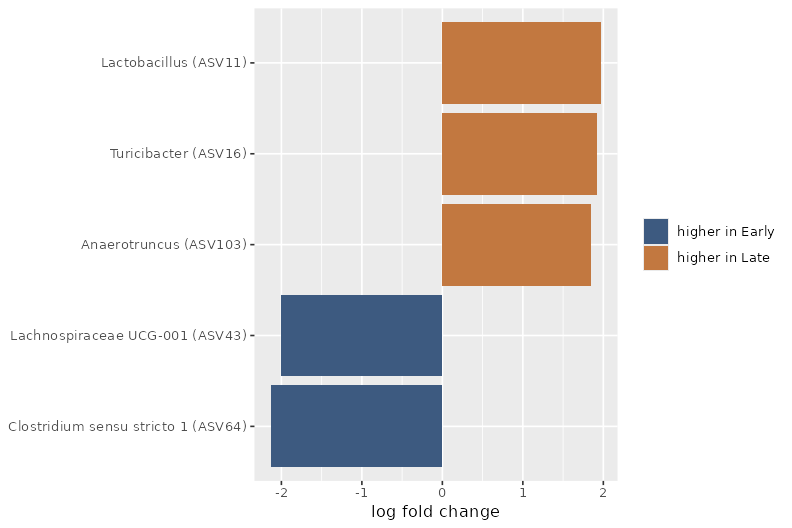

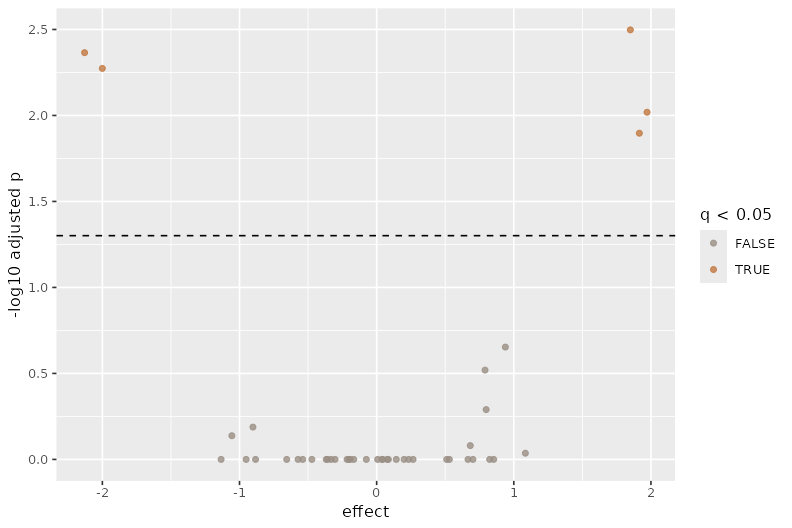

In [ ]:
step_start("n12", 13, 15, "Differential Abundance (Microbiome) (bio_expr)")
settings <- list(`method` = "ANCOM-BC2", `group_col` = "time", `reference_level` = "Early", `compare_level` = "Late", `rank` = "Genus", `min_prevalence` = 0.1, `covariates` = character(0), `alpha` = 0.05, `lda_threshold` = 2, `seed` = 1, `exclude_columns` = character(0))   # this step's settings from the canvas (tested program, pinned by the platform)
# Differential Abundance (microbiome): which taxa differ between two groups,
# by a method built for compositional count data. Each method answers the
# same question differently; the result table has the same columns for all.
if (!exists("ps") || is.null(ps) || is.null(phyloseq::sample_data(ps, errorIfNULL = FALSE))) {
  step_skipped("n12", "the feature table has no sample table with the groups to compare")
} else {
  grp <- settings$group_col
  sam <- data.frame(phyloseq::sample_data(ps), check.names = FALSE)
  if (!length(grp) || !nzchar(grp) || !(grp %in% names(sam))) {
    step_skipped("n12", paste0("the group column '", grp, "' is not in the sample table"))
  } else {
    x <- ps
    rank <- settings$rank
    if (length(rank) && nzchar(rank) && rank != "ASV" && !is.null(phyloseq::tax_table(x, errorIfNULL = FALSE)) && rank %in% phyloseq::rank_names(x)) {
      x <- phyloseq::tax_glom(x, rank, NArm = FALSE)
    }
    g <- as.character(sam[phyloseq::sample_names(x), grp])
    x <- phyloseq::prune_samples(!is.na(g) & g != "", x)
    g <- as.character(data.frame(phyloseq::sample_data(x), check.names = FALSE)[[grp]])
    levels_all <- sort(unique(g))
    ref <- if (length(settings$reference_level) && settings$reference_level %in% levels_all) settings$reference_level else levels_all[1]
    test <- if (length(settings$compare_level) && settings$compare_level %in% setdiff(levels_all, ref)) settings$compare_level else setdiff(levels_all, ref)[1]
    x <- phyloseq::prune_samples(g %in% c(ref, test), x)
    counts <- as(phyloseq::otu_table(x), "matrix"); if (!phyloseq::taxa_are_rows(x)) counts <- t(counts)
    prev <- rowMeans(counts > 0)
    counts <- counts[prev >= as.numeric(settings$min_prevalence) & rowSums(counts) > 0, , drop = FALSE]
    x <- phyloseq::prune_taxa(rownames(counts), x)
    md <- data.frame(phyloseq::sample_data(x), check.names = FALSE)
    md$group <- factor(as.character(md[[grp]]), levels = c(ref, test))
    covs <- intersect(trimws(unlist(strsplit(as.character(unlist(settings$covariates)), ","))), names(md))   # a list of columns, or "a, b"
    rhs <- paste(c("group", covs), collapse = " + ")
    alpha <- as.numeric(settings$alpha)
    label <- rownames(counts)
    if (!is.null(phyloseq::tax_table(x, errorIfNULL = FALSE))) {
      tt <- as(phyloseq::tax_table(x), "matrix")[rownames(counts), , drop = FALSE]
      best <- apply(tt, 1, function(r) { r <- r[!is.na(r) & r != ""]; if (length(r)) utils::tail(r, 1) else NA })
      label <- ifelse(is.na(best), rownames(counts), paste0(best, " (", rownames(counts), ")"))
    }
    method <- settings$method
    res <- NULL
    if (nrow(counts) < 2 || min(table(md$group)) < 2) {
      step_skipped("n12", sprintf("too little to compare: %d features and %s", nrow(counts), paste(names(table(md$group)), table(md$group), sep = " n=", collapse = ", ")))
    } else if (method == "ALDEx2") {
      set.seed(as.integer(settings$seed))
      a <- ALDEx2::aldex(as.data.frame(counts), as.character(md$group), mc.samples = 128, test = "t", effect = TRUE, denom = "all", verbose = FALSE)
      res <- data.frame(feature = rownames(a), effect = a$effect, p = a$we.ep, q = a$we.eBH)
    } else if (method == "DESeq2") {
      dds <- DESeq2::DESeqDataSetFromMatrix(countData = round(counts), colData = md, design = stats::as.formula(paste("~", rhs)))
      dds <- DESeq2::DESeq(dds, sfType = "poscounts", fitType = "local", quiet = TRUE)
      r <- DESeq2::results(dds, contrast = c("group", test, ref))
      res <- data.frame(feature = rownames(r), effect = r$log2FoldChange, p = r$pvalue, q = r$padj)
    } else if (method == "ANCOM-BC2") {
      phyloseq::sample_data(x) <- phyloseq::sample_data(md)
      o <- ANCOMBC::ancombc2(data = x, fix_formula = rhs, p_adj_method = "holm", prv_cut = 0, group = "group",
                             struc_zero = FALSE, neg_lb = FALSE, alpha = alpha, global = FALSE, n_cl = 1, verbose = FALSE)$res
      col <- paste0("group", test)
      res <- data.frame(feature = o$taxon, effect = o[[paste0("lfc_", col)]], p = o[[paste0("p_", col)]], q = o[[paste0("q_", col)]])
    } else if (method == "LinDA") {
      o <- MicrobiomeStat::linda(feature.dat = counts, meta.dat = md, formula = paste("~", rhs), feature.dat.type = "count",
                                 prev.filter = 0, alpha = alpha, verbose = FALSE)$output[[paste0("group", test)]]
      res <- data.frame(feature = rownames(o), effect = o$log2FoldChange, p = o$pvalue, q = o$padj)
    } else if (method == "MaAsLin2") {
      md2 <- md; md2$group <- as.character(md2$group)
      o <- Maaslin2::Maaslin2(input_data = as.data.frame(t(counts)), input_metadata = md2, output = tempfile("maaslin2_"),
                              fixed_effects = c("group", covs), reference = paste0("group,", ref), normalization = "TSS",
                              transform = "LOG", analysis_method = "LM", min_prevalence = 0, plot_heatmap = FALSE,
                              plot_scatter = FALSE, cores = 1)$results
      o <- o[o$metadata == "group", ]
      res <- data.frame(feature = o$feature, effect = o$coef, p = o$pval, q = o$qval)
    } else if (method == "LEfSe") {
      rel <- sweep(counts, 2, pmax(colSums(counts), 1), "/") * 1e6
      se <- SummarizedExperiment::SummarizedExperiment(assays = list(counts = rel), colData = md)
      f <- names(formals(lefser::lefser))
      col_arg <- intersect(c("groupCol", "classCol", "grp"), f)[1]
      args <- list(se, kruskal.threshold = alpha, lda.threshold = as.numeric(settings$lda_threshold))
      args[[col_arg]] <- "group"
      o <- do.call(lefser::lefser, args)
      o <- as.data.frame(o)
      res <- data.frame(feature = o[[1]], effect = o$scores, p = NA_real_, q = NA_real_)
    }
    if (!is.null(res)) {
      res$taxon <- label[match(res$feature, rownames(counts))]
      res$significant <- if (method == "LEfSe") TRUE else !is.na(res$q) & res$q < alpha
      res <- res[order(res$q, -abs(res$effect)), c("feature", "taxon", "effect", "p", "q", "significant")]
      metric("n12", "method", method)
      metric("n12", "comparison", paste(test, "vs", ref))
      metric("n12", "features_tested", nrow(counts))
      metric("n12", "significant", sum(res$significant, na.rm = TRUE))
      emit_preview("n12", res)
      data.table::fwrite(res, "artifacts/n12__differential_abundance.csv")
      sig <- res[res$significant & !is.na(res$effect), ]
      top <- utils::head(sig[order(-abs(sig$effect)), ], 25)
      if (nrow(top)) {
        top$taxon <- factor(top$taxon, levels = top$taxon[order(top$effect)])
        top$direction <- ifelse(top$effect > 0, paste("higher in", test), paste("higher in", ref))
        save_fig(ggplot2::ggplot(top, ggplot2::aes(effect, taxon, fill = direction)) + ggplot2::geom_col() +
          ggplot2::scale_fill_manual(values = stats::setNames(c("#C27840", "#3D5A80"), c(paste("higher in", test), paste("higher in", ref)))) +
          ggplot2::labs(x = switch(method, ALDEx2 = "effect size", LEfSe = "LDA score (log10)", "log fold change"), y = NULL, fill = NULL),
          "n12__differential_taxa")
      }
      if (method != "LEfSe") {
        save_fig(ggplot2::ggplot(res, ggplot2::aes(effect, -log10(pmax(q, 1e-300)), colour = significant)) + ggplot2::geom_point(alpha = 0.8) +
          ggplot2::scale_colour_manual(values = c(`TRUE` = "#C27840", `FALSE` = "#9A8F84")) +
          ggplot2::geom_hline(yintercept = -log10(alpha), linetype = "dashed") +
          ggplot2::labs(x = "effect", y = "-log10 adjusted p", colour = paste("q <", alpha)), "n12__volcano")
      }
    }
  }
}
# the fitted models (ALDEx2 Monte Carlo instances, DESeq2) are written out above and not used again
rm(list = intersect(c("x", "dds", "se"), ls())); invisible(gc())
step_done("n12", 13, 15, "Differential Abundance (Microbiome) (bio_expr)")

## Functional Prediction (PICRUSt2)

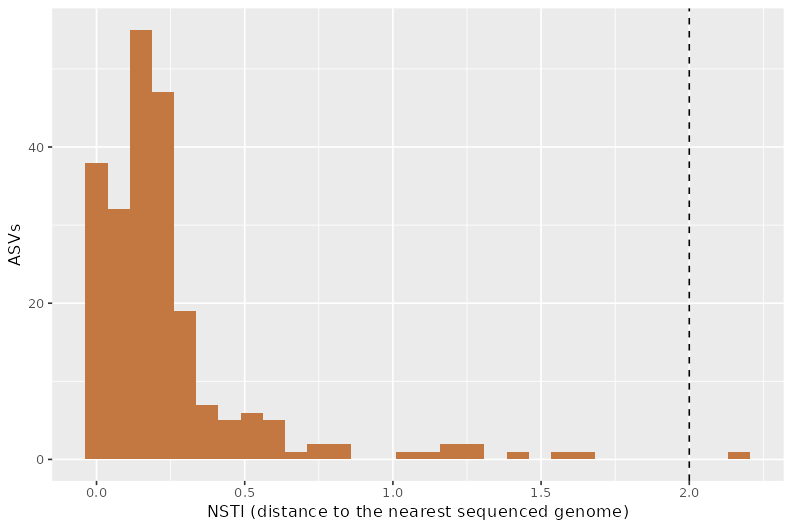

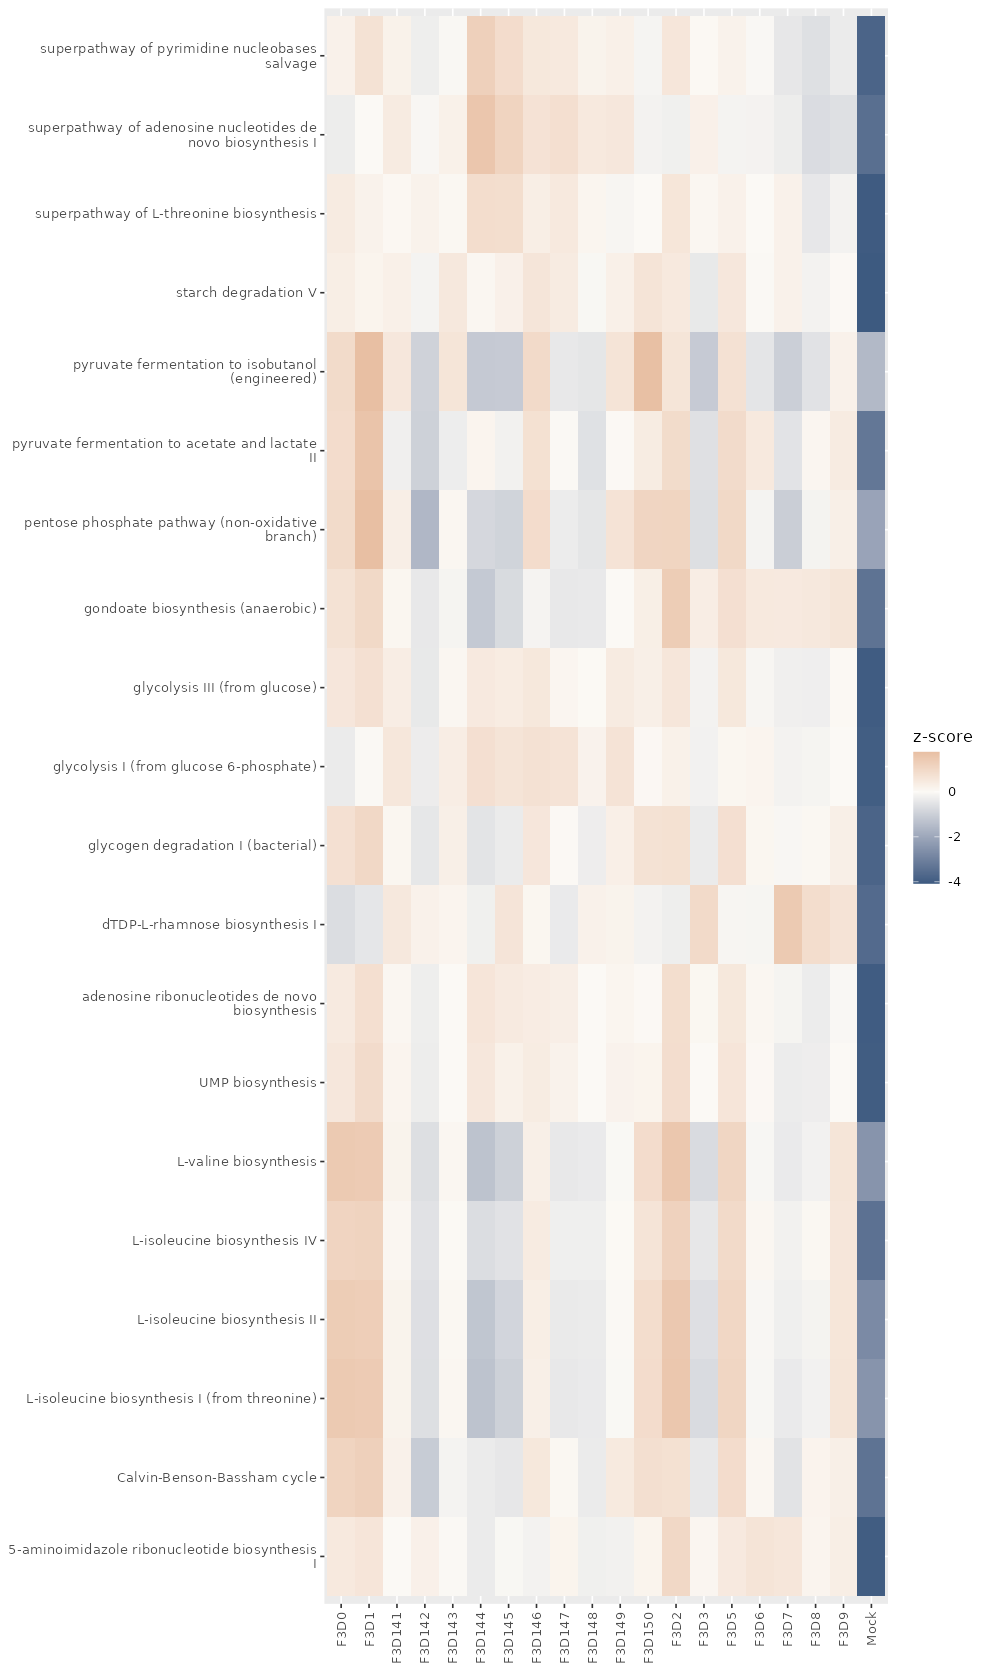

In [ ]:
step_start("n13", 6, 15, "Functional Prediction (PICRUSt2)")
settings <- list(`max_nsti` = 2, `kegg_pathways` = TRUE, `stratified` = FALSE)   # this step's settings from the canvas (tested program, pinned by the platform)
# Functional Prediction (PICRUSt2): place each ASV in a reference tree of
# sequenced genomes and predict the gene families (KEGG orthologs, EC numbers)
# and MetaCyc pathways each sample's community carries. A prediction from the
# marker gene, not a measurement: NSTI says how far each ASV is from a genome.
if (!exists("ps") || is.null(ps) || is.null(phyloseq::refseq(ps, errorIfNULL = FALSE))) {
  step_skipped("n13", "PICRUSt2 needs the ASV sequences: run ASV Inference (DADA2) first")
} else {
  counts <- as(phyloseq::otu_table(ps), "matrix"); if (!phyloseq::taxa_are_rows(ps)) counts <- t(counts)
  fa <- tempfile(fileext = ".fasta"); tab <- tempfile(fileext = ".tsv"); out <- file.path(tempdir(), "picrust2_out")
  Biostrings::writeXStringSet(phyloseq::refseq(ps), fa)
  data.table::fwrite(data.frame(`#OTU ID` = rownames(counts), counts, check.names = FALSE), tab, sep = "\t")
  # Placement with SEPP, not PICRUSt2's default EPA-ng: EPA-ng holds the whole
  # 20,000-genome reference in memory and needed more than 6.8 GB on this
  # runner (killed by the kernel), where SEPP places into subsets of the tree
  # and the whole pipeline peaked at 3.8 GB. Both are PICRUSt2's own methods.
  invisible(gc())
  # A prediction that cannot finish is reported and the run goes on: the steps
  # after it do not need it, and a killed PICRUSt2 must not take them down.
  ran <- tryCatch({
    run_tool("picrust2_pipeline.py", c("-s", fa, "-i", tab, "-o", out, "-p", "2", "-t", "sepp", "--max_nsti", as.character(settings$max_nsti),
                                       if (isTRUE(settings$stratified)) "--stratified"), node_id = "n13", timeout = 14400)
    TRUE
  }, error = function(e) conditionMessage(e))
  if (!isTRUE(ran)) {
    killed <- grepl("status -9|status 137|status -15", ran)
    step_skipped("n13", paste0("PICRUSt2 did not finish",
      if (killed) " (stopped by the system, most often for lack of memory; fewer ASVs or a larger runner)" else "",
      ": ", substr(ran, 1, 400)))
  } else {
  rd <- function(f) data.table::fread(f, data.table = FALSE)
  mapdir <- "/opt/picrust2/lib/python3.9/site-packages/picrust2/default_files"
  picrust <- list(
    ko = rd(file.path(out, "KO_metagenome_out", "pred_metagenome_unstrat.tsv.gz")),
    ec = rd(file.path(out, "EC_metagenome_out", "pred_metagenome_unstrat.tsv.gz")),
    metacyc = rd(file.path(out, "pathways_out", "path_abun_unstrat.tsv.gz")))
  if (!isFALSE(settings$kegg_pathways)) {
    kout <- file.path(tempdir(), "picrust2_kegg")
    kegg <- tryCatch({
      run_tool("pathway_pipeline.py", c("-i", file.path(out, "KO_metagenome_out", "pred_metagenome_unstrat.tsv.gz"), "-o", kout,
                                        "--no_regroup", "--map", file.path(mapdir, "pathway_mapfiles", "KEGG_pathways_to_KO.tsv"), "-p", "2"),
               node_id = "n13")
      rd(file.path(kout, "path_abun_unstrat.tsv.gz"))
    }, error = function(e) { metric("n13", "kegg_pathways_not_computed", substr(conditionMessage(e), 1, 300)); NULL })
    if (!is.null(kegg)) picrust$kegg <- kegg
  }
  nsti <- rd(file.path(out, "marker_predicted_and_nsti.tsv.gz"))
  names(nsti)[1] <- "asv"
  kept <- nsti$metadata_NSTI <= as.numeric(settings$max_nsti)
  w <- rowSums(counts)[nsti$asv]
  metric("n13", "asvs", nrow(counts))
  metric("n13", "asvs_excluded_by_nsti", sum(!kept))
  metric("n13", "weighted_mean_nsti", round(stats::weighted.mean(nsti$metadata_NSTI, w, na.rm = TRUE), 3))
  metric("n13", "ko_families", nrow(picrust$ko))
  metric("n13", "ec_numbers", nrow(picrust$ec))
  metric("n13", "metacyc_pathways", nrow(picrust$metacyc))
  if (!is.null(picrust$kegg)) metric("n13", "kegg_pathways", nrow(picrust$kegg))
  for (nm in names(picrust)) data.table::fwrite(picrust[[nm]], sprintf("artifacts/n13__%s_abundance.csv", nm))
  desc <- rd(file.path(mapdir, "description_mapfiles", "metacyc_pathways_info.txt.gz"))
  names(desc) <- c("pathway", "description")
  m <- as.matrix(picrust$metacyc[, -1]); rownames(m) <- picrust$metacyc[[1]]
  rel <- sweep(m, 2, pmax(colSums(m), 1), "/")
  top <- names(sort(rowMeans(rel), decreasing = TRUE))[seq_len(min(20, nrow(rel)))]
  z <- t(scale(t(rel[top, , drop = FALSE]))); z[is.na(z)] <- 0
  lab <- desc$description[match(top, desc$pathway)]; lab <- ifelse(is.na(lab), top, lab)
  hm <- data.frame(pathway = rep(lab, ncol(z)), sample = rep(colnames(z), each = nrow(z)), z = as.vector(z))
  save_fig(ggplot2::ggplot(hm, ggplot2::aes(sample, pathway, fill = z)) + ggplot2::geom_tile() +
    ggplot2::scale_fill_gradient2(low = "#3D5A80", mid = "#FBF9F5", high = "#C27840") +
    ggplot2::labs(x = NULL, y = NULL, fill = "z-score") +
    ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5)), "n13__top_metacyc_pathways",
    width = 9, height = 6.5)
  save_fig(ggplot2::ggplot(nsti, ggplot2::aes(metadata_NSTI)) + ggplot2::geom_histogram(bins = 30, fill = "#C27840") +
    ggplot2::geom_vline(xintercept = as.numeric(settings$max_nsti), linetype = "dashed") +
    ggplot2::labs(x = "NSTI (distance to the nearest sequenced genome)", y = "ASVs"), "n13__nsti")
  emit_preview("n13", data.frame(pathway = top, description = lab, mean_relative_abundance = round(rowMeans(rel[top, , drop = FALSE]), 5)))
}
}
step_done("n13", 6, 15, "Functional Prediction (PICRUSt2)")

## Pathway Abundance

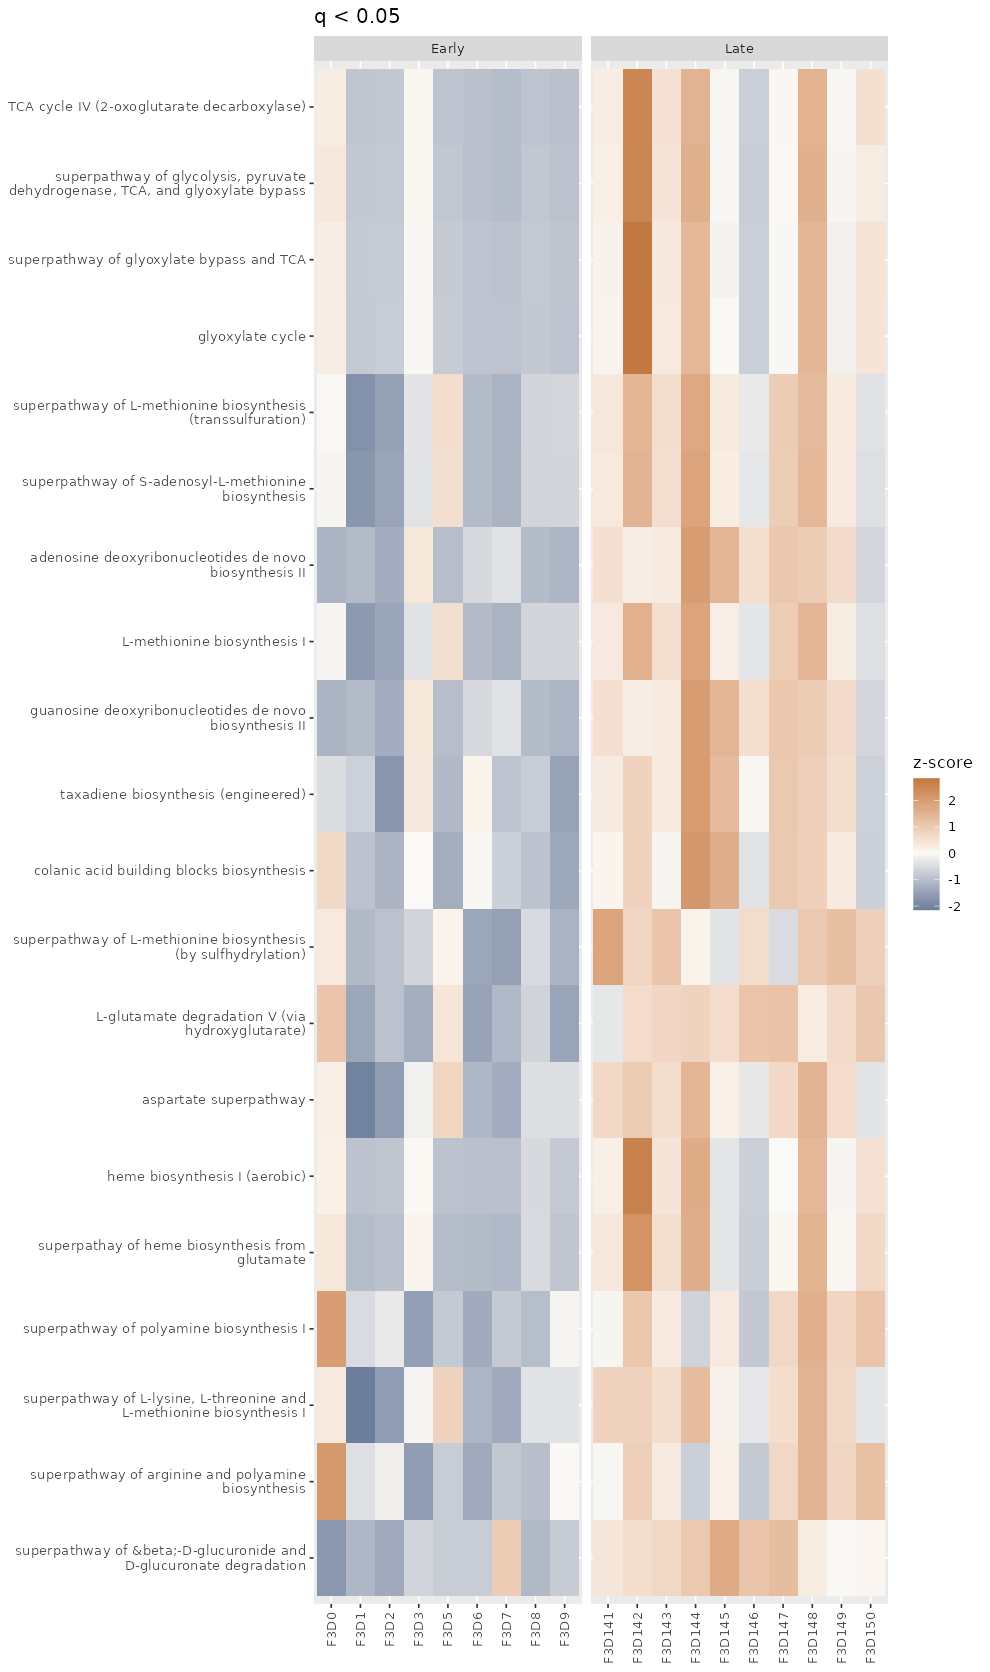

In [ ]:
step_start("n14", 7, 15, "Pathway Abundance")
settings <- list(`source` = "MetaCyc pathways", `group_col` = "time", `reference_level` = "Early", `compare_level` = "Late", `method` = "ALDEx2", `alpha` = 0.05, `top_n` = 20)   # this step's settings from the canvas (tested program, pinned by the platform)
# Pathway Abundance: compare the predicted functions between groups, as
# MetaCyc or KEGG pathways, KEGG orthologs or EC numbers, with their names.
if (!exists("picrust")) {
  step_skipped("n14", "run Functional Prediction (PICRUSt2) first")
} else if (!exists("ps") || is.null(ps) || is.null(phyloseq::sample_data(ps, errorIfNULL = FALSE))) {
  step_skipped("n14", "there is no sample table with the groups to compare")
} else {
  mapdir <- "/opt/picrust2/lib/python3.9/site-packages/picrust2/default_files/description_mapfiles"
  src <- settings$source
  tab <- switch(src, "KEGG pathways" = picrust$kegg, "KEGG orthologs" = picrust$ko, "EC numbers" = picrust$ec, picrust$metacyc)
  descfile <- switch(src, "KEGG pathways" = "KEGG_pathways_info.tsv.gz", "KEGG orthologs" = "ko_info.tsv.gz",
                     "EC numbers" = "ec_level4_info.tsv.gz", "metacyc_pathways_info.txt.gz")
  grp <- settings$group_col
  sam <- data.frame(phyloseq::sample_data(ps), check.names = FALSE)
  if (is.null(tab)) {
    step_skipped("n14", paste(src, "were not predicted: turn on KEGG pathways in Functional Prediction"))
  } else if (!length(grp) || !nzchar(grp) || !(grp %in% names(sam))) {
    step_skipped("n14", paste0("the group column '", grp, "' is not in the sample table"))
  } else {
    m <- as.matrix(tab[, -1]); rownames(m) <- tab[[1]]
    m <- m[, intersect(colnames(m), rownames(sam)), drop = FALSE]
    g <- as.character(sam[colnames(m), grp]); ok <- !is.na(g) & g != ""
    m <- m[, ok, drop = FALSE]; g <- g[ok]
    lv <- sort(unique(g))
    ref <- if (length(settings$reference_level) && settings$reference_level %in% lv) settings$reference_level else lv[1]
    test <- if (length(settings$compare_level) && settings$compare_level %in% setdiff(lv, ref)) settings$compare_level else setdiff(lv, ref)[1]
    m <- m[, g %in% c(ref, test), drop = FALSE]; g <- g[g %in% c(ref, test)]
    m <- m[rowSums(m > 0) >= 2, , drop = FALSE]
    desc <- data.table::fread(file.path(mapdir, descfile), header = FALSE, data.table = FALSE)
    lab <- desc[[2]][match(rownames(m), desc[[1]])]; lab <- ifelse(is.na(lab), rownames(m), lab)
    alpha <- as.numeric(settings$alpha)
    rel <- sweep(m, 2, pmax(colSums(m), 1), "/")
    if (settings$method == "ALDEx2") {
      set.seed(1)
      a <- ALDEx2::aldex(as.data.frame(round(m)), g, mc.samples = 128, test = "t", effect = TRUE, denom = "all", verbose = FALSE)
      res <- data.frame(feature = rownames(a), effect = a$effect, p = a$we.ep, q = a$we.eBH)
    } else if (settings$method == "LinDA") {
      md <- data.frame(group = factor(g, levels = c(ref, test)), row.names = colnames(m))
      o <- MicrobiomeStat::linda(feature.dat = round(m), meta.dat = md, formula = "~ group", feature.dat.type = "count",
                                 prev.filter = 0, alpha = alpha, verbose = FALSE)$output[[paste0("group", test)]]
      res <- data.frame(feature = rownames(o), effect = o$log2FoldChange, p = o$pvalue, q = o$padj)
    } else {
      p <- apply(rel, 1, function(v) stats::wilcox.test(v[g == test], v[g == ref], exact = FALSE)$p.value)
      eff <- log2((rowMeans(rel[, g == test, drop = FALSE]) + 1e-9) / (rowMeans(rel[, g == ref, drop = FALSE]) + 1e-9))
      res <- data.frame(feature = rownames(rel), effect = eff, p = p, q = stats::p.adjust(p, "BH"))
    }
    res$description <- lab[match(res$feature, rownames(m))]
    res$significant <- !is.na(res$q) & res$q < alpha
    res <- res[order(res$q, -abs(res$effect)), c("feature", "description", "effect", "p", "q", "significant")]
    metric("n14", "source", src)
    metric("n14", "method", settings$method)
    metric("n14", "comparison", paste(test, "vs", ref))
    metric("n14", "tested", nrow(res))
    metric("n14", "significant", sum(res$significant))
    emit_preview("n14", res)
    data.table::fwrite(res, "artifacts/n14__pathway_differences.csv")
    show <- utils::head(if (sum(res$significant)) res[res$significant, ] else res, as.integer(settings$top_n))
    z <- t(scale(t(rel[show$feature, , drop = FALSE]))); z[is.na(z)] <- 0
    hm <- data.frame(feature = rep(show$description, ncol(z)), sample = rep(colnames(z), each = nrow(z)),
                     group = rep(g, each = nrow(z)), z = as.vector(z))
    hm$feature <- factor(hm$feature, levels = rev(unique(show$description)))
    save_fig(ggplot2::ggplot(hm, ggplot2::aes(sample, feature, fill = z)) + ggplot2::geom_tile() +
      ggplot2::facet_grid(~group, scales = "free_x", space = "free_x") +
      ggplot2::scale_fill_gradient2(low = "#3D5A80", mid = "#FBF9F5", high = "#C27840") +
      ggplot2::labs(x = NULL, y = NULL, fill = "z-score", title = if (sum(res$significant)) paste0("q < ", alpha) else "none significant; the most different shown") +
      ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5)), "n14__pathway_heatmap",
      width = 9, height = max(4, 0.3 * nrow(show) + 2))
  }
}
step_done("n14", 7, 15, "Pathway Abundance")

## Mock Community Check

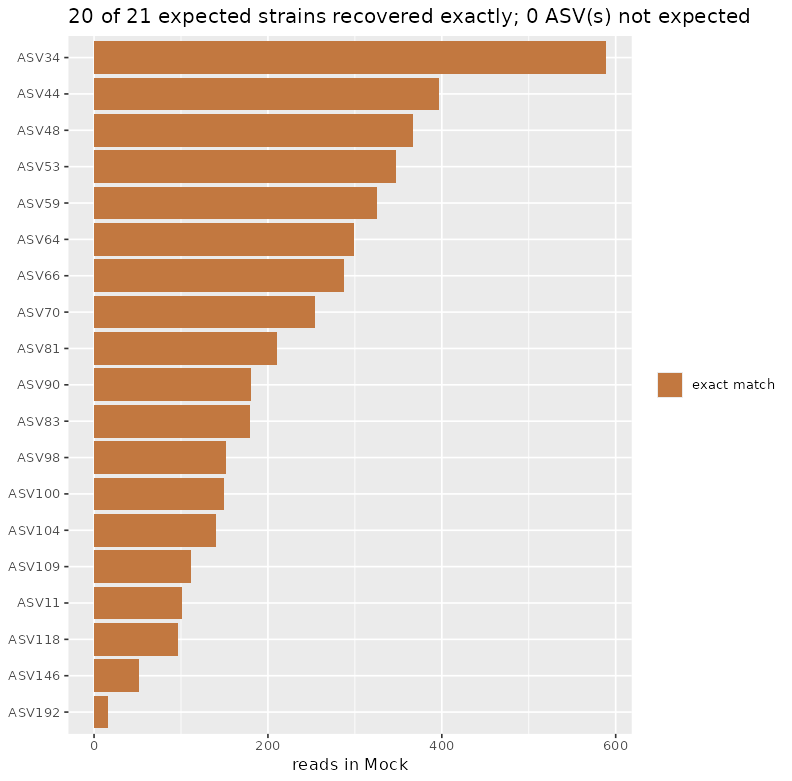

In [ ]:
step_start("n15", 5, 15, "Mock Community Check")
settings <- list(`mock_sample` = "Mock", `reference_file` = "HMP_MOCK.v35.fasta", `min_reads` = 1)   # this step's settings from the canvas (tested program, pinned by the platform)
# Mock Community Check: a sample of known composition, sequenced with the study,
# is the one place where the right answer is known. The ASVs found in it are
# compared with the expected sequences: how many expected strains were
# recovered exactly, how many ASVs match nothing expected, and how much of the
# sample those unexpected ASVs hold (contamination, chimeras, errors left in).
if (!exists("ps") || is.null(ps) || is.null(phyloseq::refseq(ps, errorIfNULL = FALSE))) {
  step_skipped("n15", "the check needs the ASV sequences: run ASV Inference (DADA2), or import a table with its sequences")
} else {
  samples <- phyloseq::sample_names(ps)
  mock <- settings$mock_sample
  if (!length(mock) || !nzchar(mock)) mock <- samples[grepl("mock", samples, ignore.case = TRUE)][1]
  fastas <- list.files("data", pattern = "[.](fasta|fa|fna)(.gz)?$", full.names = TRUE, ignore.case = TRUE)
  refname <- settings$reference_file
  ref_path <- if (length(refname) && nzchar(refname)) file.path("data", basename(refname)) else
    fastas[grepl("mock", basename(fastas), ignore.case = TRUE)][1]
  if (is.na(mock) || !(mock %in% samples)) {
    step_skipped("n15", sprintf("no mock sample: name it in the settings (samples: %s)", paste(utils::head(samples, 8), collapse = ", ")))
  } else if (!length(ref_path) || is.na(ref_path) || !file.exists(ref_path)) {
    step_skipped("n15", "no reference of the expected sequences: add a FASTA of the mock's strains to the dataset and name it in the settings")
  } else {
    ref <- Biostrings::readDNAStringSet(ref_path)
    counts <- as(phyloseq::otu_table(ps), "matrix"); if (!phyloseq::taxa_are_rows(ps)) counts <- t(counts)
    in_mock <- counts[, mock]
    in_mock <- sort(in_mock[in_mock >= max(1, as.numeric(settings$min_reads))], decreasing = TRUE)
    seqs <- phyloseq::refseq(ps)[names(in_mock)]
    both <- c(ref, Biostrings::reverseComplement(ref))
    # the fewest mismatches against any expected sequence (an ASV is a stretch of
    # the full-length 16S reference, so it is searched for inside it)
    nearest <- vapply(as.character(seqs), function(s) {
      for (k in 0:3) if (sum(Biostrings::vcountPattern(s, both, max.mismatch = k)) > 0) return(k)
      NA_real_
    }, numeric(1))
    # A strain can carry several 16S copies ("S.aureus.1", "S.aureus.2"): strains
    # are counted by name, sequences by entry. Strains whose region is identical
    # share one ASV, so an ASV names every strain it matches exactly.
    strain_of <- function(x) sub("[._-][0-9]+$", "", sub("\\s.*", "", x))
    hit_ref <- vapply(as.character(seqs), function(s) {
      i <- which(Biostrings::vcountPattern(s, both, max.mismatch = 0) > 0)
      if (length(i)) paste(unique(strain_of(names(both)[i])), collapse = "; ") else NA_character_
    }, character(1))
    res <- data.frame(asv = names(in_mock), reads = as.numeric(in_mock),
                      share = round(100 * as.numeric(in_mock) / sum(in_mock), 2),
                      mismatches = nearest, expected_strain = unname(hit_ref),
                      verdict = ifelse(!is.na(nearest) & nearest == 0, "exact match",
                                ifelse(!is.na(nearest), sprintf("%d mismatch%s", nearest, ifelse(nearest == 1, "", "es")), "not expected")))
    exact <- res$verdict == "exact match"
    strains <- unique(strain_of(names(ref)))
    found_strains <- unique(unlist(strsplit(stats::na.omit(res$expected_strain), "; ")))
    recovered <- length(found_strains)
    expected <- length(strains)
    metric("n15", "mock_sample", mock)
    metric("n15", "expected_strains", expected)
    metric("n15", "expected_sequences", length(ref))
    metric("n15", "asvs_shared_by_strains", sum(grepl(";", res$expected_strain)))
    metric("n15", "strains_missing", if (length(setdiff(strains, found_strains))) paste(setdiff(strains, found_strains), collapse = ", ") else "none")
    metric("n15", "asvs_in_mock", nrow(res))
    metric("n15", "asvs_exact_match", sum(exact))
    metric("n15", "strains_recovered", recovered)
    metric("n15", "asvs_not_expected", sum(res$verdict == "not expected"))
    metric("n15", "reads_not_exact_pct", round(100 * sum(res$reads[!exact]) / max(sum(res$reads), 1), 2))
    data.table::fwrite(res, "artifacts/n15__mock_community.csv")
    emit_preview("n15", res)
    res$asv <- factor(res$asv, levels = rev(res$asv))
    save_fig(ggplot2::ggplot(res, ggplot2::aes(asv, reads, fill = verdict)) + ggplot2::geom_col() + ggplot2::coord_flip() +
      ggplot2::scale_fill_manual(values = c("exact match" = "#C27840", "1 mismatch" = "#D9A577", "2 mismatches" = "#D9A577",
                                            "3 mismatches" = "#D9A577", "not expected" = "#3D5A80")) +
      ggplot2::labs(x = NULL, y = sprintf("reads in %s", mock), fill = NULL,
                    title = sprintf("%d of %d expected strains recovered exactly; %d ASV(s) not expected",
                                    recovered, expected, sum(res$verdict == "not expected"))),
      "n15__mock_community", width = 7.2, height = max(4, 0.25 * nrow(res) + 1.5))
  }
}
step_done("n15", 5, 15, "Mock Community Check")

## Finalize

In [ ]:
local({
  out <- as.list(METRICS)
  if (length(out) == 0) {
    # Said plainly rather than written as an empty object. A run that measured
    # nothing is nearly always a run where the steps wrote somewhere else, and
    # an empty metrics.json looks identical to a pipeline that had nothing to
    # measure.
    message("no metrics were recorded by any step")
  }
  jsonlite::write_json(out, "artifacts/metrics.json", auto_unbox = TRUE, null = "null")
})
print("pipeline finished")

## Run output

In [ ]:
# captured stdout (tail)

[1] "[[step]] n0 start 1/15 \342\226\266 Dataset"
[1] "archive data/miseq_sop_16S.zip: 40 read files, sample table sample_metadata.csv (20 rows)"
[1] "[[step]] n0 done 1/15 \342\234\223 Dataset"
[1] "[[step]] n1 start 1/4 \342\226\266 Read Quality Report"
[1] "[[step]] n1 done 1/4 \342\234\223 Read Quality Report"
[1] "[[step]] n2 start 2/4 \342\226\266 Primer Trimming (Cutadapt)"
[1] "[[step]] n2 done 2/4 \342\234\223 Primer Trimming (Cutadapt)"
[1] "[[step]] n3 start 3/4 \342\226\266 Filter & Trim Reads"
[1] "[[step]] n3 done 3/4 \342\234\223 Filter & Trim Reads"
[1] "[[step]] n4 start 4/4 \342\226\266 ASV Inference (DADA2)"
33859134 total bases in 139338 reads from 20 samples will be used for learning the error rates.
22154742 total bases in 139338 reads from 20 samples will be used for learning the error rates.
[1] "[[step]] n4 done 4/4 \342\234\223 ASV Inference (DADA2)"
[1] "[[step]] n5 start 6/15 \342\226\266 Taxonomy Assignment (bio_expr)"
[1] "[[step]] n5 done 6/15 \342\234\22

## Metrics
```json
{
  "n15::strains_recovered": 20,
  "n11::weighted_unifrac_permanova_R2": 0.3693,
  "n7::samples": 20,
  "n14::tested": 314,
  "n11::unweighted_unifrac_spread_by_group": "Early 0.195; Late 0.205",
  "n1::paired_end": true,
  "n5::classified_phylum_pct": 100,
  "n14::source": "MetaCyc pathways",
  "n1::samples": 20,
  "n12::comparison": "Late vs Early",
  "n10::Simpson_median": 0.948,
  "n10::Shannon_median": 3.425,
  "n4::asvs": 229,
  "n11::weighted_unifrac_permanova_p": 0.001,
  "n5::classified_kingdom_pct": 100,
  "n10::Faith_PD_p": 0.05,
  "n12::significant": 5,
  "n1::median_reads_per_sample": 5913.5,
  "n1::min_reads_per_sample": 3178,
  "n4::samples": 20,
  "n0::rows": 20,
  "n13::asvs": 229,
  "n11::samples_without_group_left_out": "Mock",
  "n3::reads_kept": 139338,
  "n11::jaccard_dispersion_p": 0.319,
  "n13::asvs_excluded_by_nsti": 1,
  "n2::reads_in": 152360,
  "n10::Faith_PD_median": 9.339,
  "n10::Chao1_median": 83.5,
  "n9::top_taxon": "Bacteroidota",
  "n5::classified_family_pct": 90.8,
  "n3::reads_kept_pct": 91.5,
  "n10::Pielou_median": 0.804,
  "n15::asvs_shared_by_strains": 1,
  "n6::alignment_columns": 259,
  "n6::tips": 229,
  "n12::features_tested": 52,
  "n11::weighted_unifrac_spread_by_group": "Early 0.104; Late 0.063",
  "n15::strains_missing": "P.acnes",
  "n13::ko_families": 5653,
  "n0::read_files": 40,
  "n11::unweighted_unifrac_dispersion_p": 0.707,
  "n11::jaccard_spread_by_group": "Early 0.301; Late 0.330",
  "n5::classified_order_pct": 100,
  "n3::trunc_len_reverse": 159,
  "n5::reference": "SILVA 138.1 (Zenodo 4587955), 16S",
  "n14::comparison": "Late vs Early",
  "n10::Observed_median": 83.5,
  "n11::unweighted_unifrac_permanova_R2": 0.4038,
  "n15::expected_strains": 21,
  "n12::method": "ANCOM-BC2",
  "n11::unweighted_unifrac_permanova_p": 0.001,
  "n15::expected_sequences": 32,
  "n0::columns": 4,
  "n9::top_taxon_mean_pct": 63.5,
  "n13::weighted_mean_nsti": 0.213,
  "n7::total_reads": 122931,
  "n15::reads_not_exact_pct": 0,
  "n15::asvs_exact_match": 19,
  "n14::significant": 73,
  "n4::chimeric_reads_pct": 3.69,
  "n11::distances": "Bray-Curtis, Jaccard, Unweighted UniFrac, Weighted UniFrac",
  "n11::bray_curtis_dispersion_p": 0.005,
  "n5::classified_class_pct": 100,
  "n2::primers_absent": true,
  "n3::truncation": "from the quality profile (lower quartile above Q25)",
  "n11::jaccard_permanova_R2": 0.3154,
  "n7::features": 229,
  "n10::Simpson_p": 0.624,
  "n2::reads_out": 152360,
  "n3::trunc_len_forward": 243,
  "n1::fastqc_modules_failed": 176,
  "n4::reads_retained_pct": 80.7,
  "n14::method": "ALDEx2",
  "n11::jaccard_permanova_p": 0.001,
  "n10::Pielou_p": 0.683,
  "n1::fastqc_modules_warned": 44,
  "n15::mock_sample": "Mock",
  "n13::metacyc_pathways": 341,
  "n4::reads_non_chimeric": 122931,
  "n10::Shannon_p": 0.121,
  "n2::primer_found_pct": 0,
  "n5::classified_species_pct": 6.1,
  "n10::Chao1_p": 0.165,
  "n9::rank": "Phylum",
  "n15::asvs_not_expected": 0,
  "n5::classified_genus_pct": 55,
  "n10::Observed_p": 0.165,
  "n11::bray_curtis_permanova_p": 0.001,
  "n11::weighted_unifrac_dispersion_p": 0.029,
  "n11::bray_curtis_permanova_R2": 0.4324,
  "n3::reads_in": 152360,
  "n15::asvs_in_mock": 19,
  "n13::kegg_pathways": 145,
  "n13::ec_numbers": 1752,
  "n11::bray_curtis_spread_by_group": "Early 0.224; Late 0.151",
  "n9::taxa_at_rank": 9
}
```